# **Financial Market Regime Prediction & Risk Forecasting**

# **1. Business Problem** 

Financial markets behave differently across periods of low volatility, strong
growth, high uncertainty, and financial stress. Identifying these market
regimes and anticipating transitions toward higher-risk conditions can support
financial risk monitoring and portfolio analysis.

# **2. Project Objective & Data Scope**

**A. Data Scope**

This project uses financial and macroeconomic data from **January 2005 to
December 2025** to identify historical market regimes and predict future
higher-risk conditions using machine learning.

The 2005–2025 period captures several contrasting market environments,
including the 2008 Global Financial Crisis, the 2020 COVID-19 market shock,
the 2022 inflation and monetary-tightening cycle, and subsequent market
conditions.

**B. Objectives**

- Identify distinct market regimes using unsupervised ML.
- Analyze the characteristics and transitions of these regimes.
- Predict future market regimes using supervised ML.
- Forecast the probability of higher-risk conditions.

# **3. Importing Libraries**

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    f1_score
)
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# **4. Data Understanding** 

In [2]:
# Importing FRED datasets

fedfunds = pd.read_csv(
    "/kaggle/input/datasets/sb100500/federal-reserve-bank-data2005-2025/FEDFUNDS.csv"
)

stlfsi4 = pd.read_csv(
    "/kaggle/input/datasets/sb100500/federal-reserve-bank-data2005-2025/STLFSI4.csv"
)

dgs10 = pd.read_csv(
    "/kaggle/input/datasets/sb100500/federal-reserve-bank-data2005-2025/DGS10.csv"
)

unrate = pd.read_csv(
    "/kaggle/input/datasets/sb100500/federal-reserve-bank-data2005-2025/UNRATE.csv"
)

cpi = pd.read_csv(
    "/kaggle/input/datasets/sb100500/federal-reserve-bank-data2005-2025/CPIAUCSL.csv"
)

dgs2 = pd.read_csv(
    "/kaggle/input/datasets/sb100500/federal-reserve-bank-data2005-2025/DGS2.csv"
)

dgs30 = pd.read_csv(
    "/kaggle/input/datasets/sb100500/federal-reserve-bank-data2005-2025/DGS30.csv"
)

In [3]:
fedfunds.head()

,observation_date,FEDFUNDS
0,1954-07-01,0.80
1,1954-08-01,1.22
2,1954-09-01,1.07
3,1954-10-01,0.85
4,1954-11-01,0.83


In [4]:
stlfsi4.head()

,observation_date,STLFSI4
0,1993-12-31,-0.2901
1,1994-01-07,-0.3670
2,1994-01-14,-0.1064
3,1994-01-21,-0.3436
4,1994-01-28,-0.2127


In [5]:
dgs10.head()

,observation_date,DGS10
0,2005-01-03,4.23
1,2005-01-04,4.29
2,2005-01-05,4.29
3,2005-01-06,4.29
4,2005-01-07,4.29


In [6]:
unrate.head()

,observation_date,UNRATE
0,1948-01-01,3.4
1,1948-02-01,3.8
2,1948-03-01,4.0
3,1948-04-01,3.9
4,1948-05-01,3.5


In [7]:
cpi.head()

,observation_date,CPIAUCSL
0,1947-01-01,21.48
1,1947-02-01,21.62
2,1947-03-01,22.00
3,1947-04-01,22.00
4,1947-05-01,21.95


In [8]:
dgs2.head()

,observation_date,DGS2
0,2005-01-03,3.10
1,2005-01-04,3.20
2,2005-01-05,3.22
3,2005-01-06,3.18
4,2005-01-07,3.20


In [9]:
dgs30.head()

,observation_date,DGS30
0,2005-01-03,4.85
1,2005-01-04,4.91
2,2005-01-05,4.88
3,2005-01-06,4.89
4,2005-01-07,4.88


In [10]:
# Importing Yahoo Finance dataset

yahoo = pd.read_csv(
    "/kaggle/input/datasets/sb100500/yahoo-finance/market_data.csv"
)

yahoo.head()

,Price,Adj Close,Adj Close.1,Adj Close.2,Adj Close.3,Adj Close.4,Adj Close.5,Adj Close.6,Adj Close.7,Close,...,Open.6,Open.7,Volume,Volume.1,Volume.2,Volume.3,Volume.4,Volume.5,Volume.6,Volume.7
0,Ticker,CL=F,EURUSD=X,GC=F,JPY=X,^DJI,^GSPC,^IXIC,^VIX,CL=F,...,^IXIC,^VIX,CL=F,EURUSD=X,GC=F,JPY=X,^DJI,^GSPC,^IXIC,^VIX
1,Date,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2005-01-03,42.119998931884766,1.3470009565353394,428.70001220703125,102.73999786376953,10729.4296875,1202.0799560546875,2152.14990234375,14.079999923706055,42.119998931884766,...,2184.75,13.390000343322754,69484.0,0.0,4.0,0.0,270620000.0,1510800000.0,2193130000.0,0.0
3,2005-01-04,43.90999984741211,1.3281975984573364,428.5,104.33999633789062,10630.7802734375,1188.050048828125,2107.860107421875,13.979999542236328,43.90999984741211,...,2158.31005859375,14.010000228881836,100665.0,0.0,108.0,0.0,293280000.0,1721000000.0,2690460000.0,0.0
4,2005-01-05,43.38999938964844,1.3280036449432373,426.6000061035156,103.93000030517578,10597.830078125,1183.739990234375,2091.239990234375,14.09000015258789,43.38999938964844,...,2102.89990234375,13.979999542236328,91011.0,0.0,2.0,0.0,263550000.0,1738900000.0,2375380000.0,0.0


In [11]:
# Importing Kenneth French 5-Factor dataset
ff5_path = "/kaggle/input/datasets/sb100500/kenneth-french-data-library/F-F_Research_Data_5_Factors_2x3_daily.csv"

with open(ff5_path, "r") as file:
    for i in range(15):
        print(i, repr(file.readline()))

#skiprows=4 as first 4 lines include metadata which is not interpreted by read_csv()
ff5 = pd.read_csv(
    "/kaggle/input/datasets/sb100500/kenneth-french-data-library/F-F_Research_Data_5_Factors_2x3_daily.csv",
    skiprows=4
)

ff5.head()

0 'This file was created by using the 202606 CRSP database.\n'
1 'The Tbill return is the simple daily rate that, over the number of trading days\n'
2 'compounds to 1-month TBill rate. The 1-month TBill rate data until 202405 are from Ibbotson Associates. Starting from 202406, the 1-month TBill rate is from ICE BofA US 1-Month Treasury Bill Index.\n'
3 '\n'
4 ',Mkt-RF,SMB,HML,RMW,CMA,RF\n'
5 '19630701,   -0.67,    0.00,   -0.34,   -0.01,    0.16,    0.01\n'
6 '19630702,    0.79,   -0.26,    0.26,   -0.07,   -0.20,    0.01\n'
7 '19630703,    0.63,   -0.17,   -0.09,    0.18,   -0.34,    0.01\n'
8 '19630705,    0.40,    0.08,   -0.27,    0.09,   -0.34,    0.01\n'
9 '19630708,   -0.63,    0.04,   -0.18,   -0.29,    0.14,    0.01\n'
10 '19630709,    0.45,    0.00,    0.09,    0.14,   -0.05,    0.01\n'
11 '19630710,   -0.18,    0.21,    0.01,    0.06,   -0.08,    0.01\n'
12 '19630711,   -0.16,    0.15,   -0.30,   -0.07,    0.05,    0.01\n'
13 '19630712,   -0.12,    0.01,   -0.09,    0.11,   

,Unnamed: 0,Mkt-RF,SMB,HML,RMW,CMA,RF
0,19630701,-0.67,0.00,-0.34,-0.01,0.16,0.01
1,19630702,0.79,-0.26,0.26,-0.07,-0.20,0.01
2,19630703,0.63,-0.17,-0.09,0.18,-0.34,0.01
3,19630705,0.40,0.08,-0.27,0.09,-0.34,0.01
4,19630708,-0.63,0.04,-0.18,-0.29,0.14,0.01


In [12]:
# Importing Kenneth French Momentum Factor

mom_path = "/kaggle/input/datasets/sb100500/kenneth-french-data-library/F-F_Momentum_Factor_daily.csv"

with open(mom_path, "r") as file:
    for i in range(20):
        print(i, repr(file.readline()))

#Lines 0–12 = metadata
#Line 13 = column header
#Line 14 onward = actual data
mom = pd.read_csv(
    mom_path,
    skiprows=13
)

mom.head()

0 'This file was created by using the 202606 CRSP database.  It\n'
1 'contains a momentum factor, constructed from six value-weight portfolios formed\n'
2 'using independent sorts on size and prior return of NYSE, AMEX, and NASDAQ stocks.\n'
3 'MOM is the average of the returns on two (big and small) high prior return portfolios\n'
4 'minus the average of the returns on two low prior return portfolios.  The portfolios\n'
5 'are constructed daily.  Big means a firm is above the median market cap on the NYSE\n'
6 'at the end of the previous day; small firms are below the median NYSE market cap.\n'
7 'Prior return is measured from day - 250 to - 21.  Firms in the low prior return\n'
8 'portfolio are below the 30th NYSE percentile.  Those in the high portfolio are above\n'
9 'the 70th NYSE percentile.\n'
10 '\n'
11 'Missing data are indicated by -99.99 or -999.\n'
12 '\n'
13 ',Mom\n'
14 '19261103,   0.35\n'
15 '19261104,  -0.61\n'
16 '19261105,   1.15\n'
17 '19261106,  -0.18\n'
18 '1926110

,Unnamed: 0,Mom
0,19261103,0.35
1,19261104,-0.61
2,19261105,1.15
3,19261106,-0.18
4,19261108,-0.05


In [13]:
# Shape of the datasets

print("FRED")
print("FEDFUNDS:", fedfunds.shape)
print("STLFSI4:", stlfsi4.shape)
print("DGS10:", dgs10.shape)
print("UNRATE:", unrate.shape)
print("CPI:", cpi.shape)
print("DGS2:", dgs2.shape)
print("DGS30:", dgs30.shape)

print("\nYAHOO")
print("Yahoo:", yahoo.shape)

print("\nKENNETH FRENCH")
print("Fama-French 5 Factors:", ff5.shape)
print("Momentum:", mom.shape)

FRED
FEDFUNDS: (865, 2)
STLFSI4: (1702, 2)
DGS10: (5478, 2)
UNRATE: (943, 2)
CPI: (955, 2)
DGS2: (5478, 2)
DGS30: (5478, 2)

YAHOO
Yahoo: (5639, 49)

KENNETH FRENCH
Fama-French 5 Factors: (15855, 7)
Momentum: (26174, 2)


In [14]:
# Identify columns of the datasets

datasets = {
    "FEDFUNDS": fedfunds,
    "STLFSI4": stlfsi4,
    "DGS10": dgs10,
    "UNRATE": unrate,
    "CPI": cpi,
    "DGS2": dgs2,
    "DGS30": dgs30,
    "Yahoo": yahoo,
    "Fama-French 5 Factors": ff5,
    "Momentum": mom
}

for name, df in datasets.items():
    print(f"\n{name}")
    print(df.columns.tolist())


FEDFUNDS
['observation_date', 'FEDFUNDS']

STLFSI4
['observation_date', 'STLFSI4']

DGS10
['observation_date', 'DGS10']

UNRATE
['observation_date', 'UNRATE']

CPI
['observation_date', 'CPIAUCSL']

DGS2
['observation_date', 'DGS2']

DGS30
['observation_date', 'DGS30']

Yahoo
['Price', 'Adj Close', 'Adj Close.1', 'Adj Close.2', 'Adj Close.3', 'Adj Close.4', 'Adj Close.5', 'Adj Close.6', 'Adj Close.7', 'Close', 'Close.1', 'Close.2', 'Close.3', 'Close.4', 'Close.5', 'Close.6', 'Close.7', 'High', 'High.1', 'High.2', 'High.3', 'High.4', 'High.5', 'High.6', 'High.7', 'Low', 'Low.1', 'Low.2', 'Low.3', 'Low.4', 'Low.5', 'Low.6', 'Low.7', 'Open', 'Open.1', 'Open.2', 'Open.3', 'Open.4', 'Open.5', 'Open.6', 'Open.7', 'Volume', 'Volume.1', 'Volume.2', 'Volume.3', 'Volume.4', 'Volume.5', 'Volume.6', 'Volume.7']

Fama-French 5 Factors
['Unnamed: 0', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']

Momentum
['Unnamed: 0', 'Mom']


In [15]:
# Time period of the datasets

for name, df in datasets.items():
    print(f"\n{name}")
    print("First row:")
    print(df.iloc[0])
    print("Last row:")
    print(df.iloc[-1])


FEDFUNDS
First row:
observation_date    1954-07-01
FEDFUNDS                   0.8
Name: 0, dtype: object
Last row:
observation_date    2026-07-01
FEDFUNDS                  3.63
Name: 864, dtype: object

STLFSI4
First row:
observation_date    1993-12-31
STLFSI4                -0.2901
Name: 0, dtype: object
Last row:
observation_date    2026-08-07
STLFSI4                -0.7709
Name: 1701, dtype: object

DGS10
First row:
observation_date    2005-01-03
DGS10                     4.23
Name: 0, dtype: object
Last row:
observation_date    2025-12-31
DGS10                     4.18
Name: 5477, dtype: object

UNRATE
First row:
observation_date    1948-01-01
UNRATE                     3.4
Name: 0, dtype: object
Last row:
observation_date    2026-07-01
UNRATE                     4.1
Name: 942, dtype: object

CPI
First row:
observation_date    1947-01-01
CPIAUCSL                 21.48
Name: 0, dtype: object
Last row:
observation_date    2026-07-01
CPIAUCSL               332.813
Name: 954, dtype: o

### Feature Exclusion: BAMLH0A0HYM2

The BAMLH0A0HYM2 high-yield credit spread was excluded from the primary
modeling dataset because its available historical data begins in 2023,
while the project covers 2005–2025.

Including it would substantially reduce the historical observations
available for model training or require extensive imputation.

The remaining variables provide sufficient coverage of market volatility,
financial stress, interest rates, macroeconomic conditions, commodities,
and equity-market behavior.

In [16]:
# Data Types

for name, df in datasets.items():
    print(f"\n{'='*50}")
    print(name)
    print(df.info())


FEDFUNDS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 865 entries, 0 to 864
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  865 non-null    object 
 1   FEDFUNDS          865 non-null    float64
dtypes: float64(1), object(1)
memory usage: 13.6+ KB
None

STLFSI4
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1702 entries, 0 to 1701
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  1702 non-null   object 
 1   STLFSI4           1702 non-null   float64
dtypes: float64(1), object(1)
memory usage: 26.7+ KB
None

DGS10
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5478 entries, 0 to 5477
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  5478 non-null   object 
 1   DGS10             52

In [17]:
# Missing Value Check

for name, df in datasets.items():
    print(f"\n{'='*50}")
    print(name)
    print(df.isnull().sum())


FEDFUNDS
observation_date    0
FEDFUNDS            0
dtype: int64

STLFSI4
observation_date    0
STLFSI4             0
dtype: int64

DGS10
observation_date      0
DGS10               225
dtype: int64

UNRATE
observation_date    0
UNRATE              1
dtype: int64

CPI
observation_date    0
CPIAUCSL            1
dtype: int64

DGS2
observation_date      0
DGS2                225
dtype: int64

DGS30
observation_date      0
DGS30               225
dtype: int64

Yahoo
Price            0
Adj Close      201
Adj Close.1     31
Adj Close.2    205
Adj Close.3     30
Adj Close.4    200
Adj Close.5    200
Adj Close.6    200
Adj Close.7    199
Close          201
Close.1         31
Close.2        205
Close.3         30
Close.4        200
Close.5        200
Close.6        200
Close.7        199
High           201
High.1          31
High.2         205
High.3          30
High.4         200
High.5         200
High.6         200
High.7         199
Low            201
Low.1           31
Low.2          20

In [18]:
# diagnos the DGS10----225 missing values
dgs10[dgs10['DGS10'].isnull()].head(20)

,observation_date,DGS10
10,2005-01-17,NaN
35,2005-02-21,NaN
59,2005-03-25,NaN
105,2005-05-30,NaN
130,2005-07-04,NaN
175,2005-09-05,NaN
200,2005-10-10,NaN
224,2005-11-11,NaN
233,2005-11-24,NaN
255,2005-12-26,NaN


In [19]:
#Diagnos DGS30 missing values
dgs30[dgs30['DGS30'].isnull()].head(20)

,observation_date,DGS30
10,2005-01-17,NaN
35,2005-02-21,NaN
59,2005-03-25,NaN
105,2005-05-30,NaN
130,2005-07-04,NaN
175,2005-09-05,NaN
200,2005-10-10,NaN
224,2005-11-11,NaN
233,2005-11-24,NaN
255,2005-12-26,NaN


In [20]:
#diagnos DGS2 missing values
dgs2[dgs2['DGS2'].isnull()].head(20)

,observation_date,DGS2
10,2005-01-17,NaN
35,2005-02-21,NaN
59,2005-03-25,NaN
105,2005-05-30,NaN
130,2005-07-04,NaN
175,2005-09-05,NaN
200,2005-10-10,NaN
224,2005-11-11,NaN
233,2005-11-24,NaN
255,2005-12-26,NaN


In [21]:
#diagnos CPIAUCSL missing values---only 1 missing value
cpi[cpi['CPIAUCSL'].isnull()]

,observation_date,CPIAUCSL
945,2025-10-01,NaN


In [22]:
#diagnos UNRATE missing values--- only 1 missing value
unrate[unrate['UNRATE'].isnull()]

,observation_date,UNRATE
933,2025-10-01,NaN


### FRED Missing Values — Conclusion

Missing values in the Treasury yield series correspond primarily to U.S.
market holidays, while the isolated missing observations in CPI and UNRATE
will be handled during preprocessing. These are not considered major data
quality issues.

In [23]:
#Yahoo Finance missing value check
yahoo.isnull().sum().sort_values(ascending=False)


Adj Close.2    205
Close.2        205
Volume.2       205
Low.2          205
High.2         205
Open.2         205
Close          201
Adj Close      201
Open           201
High           201
Low            201
Volume         201
Close.6        200
Adj Close.6    200
Close.5        200
Adj Close.5    200
Adj Close.4    200
Volume.6       200
Volume.4       200
Open.5         200
Open.4         200
High.6         200
Low.5          200
High.5         200
Close.4        200
Low.6          200
Low.4          200
Volume.5       200
Open.6         200
High.4         200
Low.7          199
Adj Close.7    199
Close.7        199
Open.7         199
High.7         199
Volume.7       199
Volume.1        31
Close.1         31
Open.1          31
High.1          31
Adj Close.1     31
Low.1           31
Low.3           30
Adj Close.3     30
Close.3         30
Open.3          30
High.3          30
Volume.3        30
Price            0
dtype: int64

### Yahoo Finance Missing Values — Conclusion

Missing values are mainly caused by differences in trading calendars across
equities, commodities, currencies, and volatility markets. These are expected
market-data gaps and will be handled during date alignment and preprocessing.

In [24]:
# kenneth French Dataset- missing values check
ff5.tail()

,Unnamed: 0,Mkt-RF,SMB,HML,RMW,CMA,RF
15850,20260625,-0.13,0.61,0.91,-0.76,0.51,0.01
15851,20260626,0.15,1.36,-0.95,0.44,0.04,0.01
15852,20260629,1.20,-0.89,-0.90,-1.77,-0.50,0.01
15853,20260630,0.73,-0.10,-0.62,-1.10,-0.49,0.01
15854,Copyright 2026 Eugene F. Fama and Kenneth R. F...,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
mom.tail()

,Unnamed: 0,Mom
26169,20260625,1.62
26170,20260626,-3.18
26171,20260629,1.66
26172,20260630,1.06
26173,Copyright 2026 Eugene F. Fama and Kenneth R. F...,NaN


### Kenneth French Missing Values — Conclusion

The missing values in the Fama-French 5-Factor and Momentum datasets are
caused by the copyright/footer rows present at the end of the downloaded
files. These rows will be removed during data cleaning.

In [26]:
#Statistical Summary
for name,df in datasets.items():
    print(f"\n{'='*50}")
    print(name)
    display(df.describe())


FEDFUNDS


,FEDFUNDS
count,865.000000
mean,4.595965
std,3.529598
min,0.050000
25%,1.930000
50%,4.260000
75%,6.120000
max,19.100000



STLFSI4


,STLFSI4
count,1.702000e+03
mean,-4.700353e-07
std,9.999989e-01
min,-1.127000e+00
25%,-5.357750e-01
50%,-2.100000e-01
75%,2.445000e-01
max,9.676600e+00



DGS10


...

,Price,Adj Close,Adj Close.1,Adj Close.2,Adj Close.3,Adj Close.4,Adj Close.5,Adj Close.6,Adj Close.7,Close,...,Open.6,Open.7,Volume,Volume.1,Volume.2,Volume.3,Volume.4,Volume.5,Volume.6,Volume.7
count,5639,5438,5608,5434,5609,5439,5439,5439,5440,5438,...,5439,5440,5438,5608,5434,5609,5439,5439,5439,5440
unique,5639,3881,4686,4507,5048,5420,5388,5414,2116,3881,...,5412,2084,5388,2,1570,2,5106,5361,5372,2
top,2026-08-16,44.65999984741211,1.285000205039978,1273.699951171875,89.80999755859375,18533.05078125,2783.02001953125,2069.0400390625,12.850000381469727,44.65999984741211,...,2432.550048828125,13.350000381469727,0.0,0.0,0.0,0.0,301750000.0,4223740000.0,1943820000.0,0.0
freq,1,6,5,6,4,2,2,2,13,6,...,2,14,7,5607,150,5608,4,12,2,5439



Fama-French 5 Factors


,Mkt-RF,SMB,HML,RMW,CMA,RF
count,15854.000000,15854.000000,15854.000000,15854.000000,15854.000000,15854.000000
mean,0.029049,0.006268,0.014910,0.011656,0.011895,0.017160
std,1.021921,0.551188,0.587329,0.410374,0.384155,0.012686
min,-17.440000,-11.150000,-5.030000,-2.970000,-5.310000,0.000000
25%,-0.420000,-0.280000,-0.240000,-0.180000,-0.180000,0.010000
50%,0.050000,0.020000,0.010000,0.010000,0.010000,0.020000
75%,0.510000,0.310000,0.260000,0.190000,0.200000,0.020000
max,11.360000,6.080000,6.730000,4.570000,2.480000,0.060000



Momentum


,Mom
count,26173.000000
mean,0.026317
std,0.789643
min,-18.230000
25%,-0.250000
50%,0.060000
75%,0.360000
max,7.120000


### Descriptive Statistics — Conclusion

The statistical summary shows substantial variation across the financial
and macroeconomic variables. Interest rates, unemployment, financial stress,
market returns, and asset prices exhibit different scales and distributions.

Several variables also contain extreme observations, particularly financial
stress and market-return factors. These values will not be removed as
outliers automatically, since extreme market movements may represent genuine
financial events.

The Yahoo Finance dataset requires structural cleaning before meaningful
numerical statistics can be interpreted.

# **5. Data Cleaning**

In [27]:
#F-F Research data 5 factors dataset- Remove footer and make it proper date field
#str.match(r"^\d+$")]- here ^ is the start of the value, \d define digits 0-9 + this one or more digits and finally $ means end of value

ff5 = ff5[ff5["Unnamed: 0"].astype(str).str.match(r"^\d+$")].copy()
#check whether the footer has got removed
ff5.tail()

#Fix the column name for ff5
ff5.rename(columns={"Unnamed: 0":"Date"},inplace=True)
ff5.head()

#Change the format of the date 
ff5["Date"]=pd.to_datetime(ff5["Date"],format="%Y%m%d")
ff5.head()

,Date,Mkt-RF,SMB,HML,RMW,CMA,RF
0,1963-07-01,-0.67,0.00,-0.34,-0.01,0.16,0.01
1,1963-07-02,0.79,-0.26,0.26,-0.07,-0.20,0.01
2,1963-07-03,0.63,-0.17,-0.09,0.18,-0.34,0.01
3,1963-07-05,0.40,0.08,-0.27,0.09,-0.34,0.01
4,1963-07-08,-0.63,0.04,-0.18,-0.29,0.14,0.01


In [28]:
#Check the data type and null count check
ff5.dtypes
ff5.isnull().sum()

Date      0
Mkt-RF    0
SMB       0
HML       0
RMW       0
CMA       0
RF        0
dtype: int64

### Fama-French 5 Factors — Cleaning Conclusion

The Fama-French 5-Factor dataset was cleaned by removing the non-data
copyright/footer row and converting the observation date to datetime format.
The factor variables were already numeric and contained no missing values.
The dataset is ready for further preprocessing.

In [29]:
#F-F Momentum Factor Daily Dataset- Remove the footer and make it a date field only
mom = mom[mom["Unnamed: 0"].astype(str).str.match(r"^\d+$")].copy()
mom.tail()

#Now we have to change the field name to Date
mom.rename(columns={"Unnamed: 0":"Date"},inplace=True)
mom.head()

#Change the date format
mom["Date"]=pd.to_datetime(mom["Date"],format="%Y%m%d")
mom.head()

,Date,Mom
0,1926-11-03,0.35
1,1926-11-04,-0.61
2,1926-11-05,1.15
3,1926-11-06,-0.18
4,1926-11-08,-0.05


In [30]:
#Check the data types and null check
mom.dtypes
mom.isnull().sum()

Date    0
Mom     0
dtype: int64

In [31]:
#Change the observation_date column of all fed datasets to Date
fedfunds.rename(columns={"observation_date":"Date"},inplace=True)
cpi.rename(columns={"observation_date":"Date"},inplace=True)
dgs2.rename(columns={"observation_date":"Date"},inplace=True)
dgs10.rename(columns={"observation_date":"Date"},inplace=True)
dgs30.rename(columns={"observation_date":"Date"},inplace=True)
unrate.rename(columns={"observation_date":"Date"},inplace=True)
stlfsi4.rename(columns={"observation_date":"Date"},inplace=True)

#Change the date field to date time to convert the datatype from object to datetime standard format
fedfunds["Date"]=pd.to_datetime(fedfunds["Date"])
cpi["Date"]=pd.to_datetime(cpi["Date"])
unrate["Date"]=pd.to_datetime(unrate["Date"])
dgs2["Date"]=pd.to_datetime(dgs2["Date"])
dgs10["Date"]=pd.to_datetime(dgs10["Date"])
dgs30["Date"]=pd.to_datetime(dgs30["Date"])
stlfsi4["Date"]=pd.to_datetime(stlfsi4["Date"])

#Check the changes-evaluation for any one field is enough
fedfunds.head()

#check the data type as well
fedfunds.dtypes

Date        datetime64[ns]
FEDFUNDS           float64
dtype: object

In [32]:
#Handle the isolated CPI and UNRATE missing values

unrate["UNRATE"] = unrate["UNRATE"].interpolate(method="linear")
cpi["CPIAUCSL"] = cpi["CPIAUCSL"].interpolate(method="linear")

#check whether any null values
print(unrate["UNRATE"].isnull().sum())
print(cpi["CPIAUCSL"].isnull().sum())

0
0


### Missing Value Treatment — Conclusion

The isolated missing observations in CPI and UNRATE were handled using
linear interpolation based on the surrounding time-series observations.
This preserves the continuity of the monthly economic indicators without
introducing a global statistic such as the mean or median.

The Treasury yield gaps were retained as they correspond to market holidays
and will be addressed during date alignment rather than artificially
imputed.

The ticker row was extracted to identify the financial instrument associated
with each Yahoo Finance price column, since the raw dataset used duplicate
generic column names such as `Adj Close`, `Adj Close.1`, etc.

In [33]:
#Extract the ticker information-Yahoo Finance Dataset
ticker_row = yahoo.iloc[0, 1:]

ticker_row

Adj Close          CL=F
Adj Close.1    EURUSD=X
Adj Close.2        GC=F
Adj Close.3       JPY=X
Adj Close.4        ^DJI
Adj Close.5       ^GSPC
Adj Close.6       ^IXIC
Adj Close.7        ^VIX
Close              CL=F
Close.1        EURUSD=X
Close.2            GC=F
Close.3           JPY=X
Close.4            ^DJI
Close.5           ^GSPC
Close.6           ^IXIC
Close.7            ^VIX
High               CL=F
High.1         EURUSD=X
High.2             GC=F
High.3            JPY=X
High.4             ^DJI
High.5            ^GSPC
High.6            ^IXIC
High.7             ^VIX
Low                CL=F
Low.1          EURUSD=X
Low.2              GC=F
Low.3             JPY=X
Low.4              ^DJI
Low.5             ^GSPC
Low.6             ^IXIC
Low.7              ^VIX
Open               CL=F
Open.1         EURUSD=X
Open.2             GC=F
Open.3            JPY=X
Open.4             ^DJI
Open.5            ^GSPC
Open.6            ^IXIC
Open.7             ^VIX
Volume             CL=F
Volume.1       E

In [34]:
#Create the clean price dataset
yahoo_clean = yahoo.iloc[2:, [0, 1, 2, 3, 4, 5, 6, 7, 8]].copy()

#Rename the selected columns
yahoo_clean.columns = [
    "Date",
    "Crude_Oil",
    "EUR_USD",
    "Gold",
    "USD_JPY",
    "Dow_Jones",
    "S&P_500",
    "NASDAQ",
    "VIX"
]
#Convert the data type of the date column
yahoo_clean["Date"] = pd.to_datetime(yahoo_clean["Date"])

#Convert market variables to numeric
price_cols = [
    "Crude_Oil",
    "EUR_USD",
    "Gold",
    "USD_JPY",
    "Dow_Jones",
    "S&P_500",
    "NASDAQ",
    "VIX"
]

yahoo_clean[price_cols] = yahoo_clean[price_cols].apply(
    pd.to_numeric,
    errors="coerce"
)

yahoo_clean.head()
yahoo_clean.dtypes

Date         datetime64[ns]
Crude_Oil           float64
EUR_USD             float64
Gold                float64
USD_JPY             float64
Dow_Jones           float64
S&P_500             float64
NASDAQ              float64
VIX                 float64
dtype: object

The raw Yahoo Finance dataset contains multiple OHLCV variables for each
asset. Since the project focuses on market regime identification and risk
forecasting rather than intraday trading, only the Adjusted Close price
series were retained. These prices provide the basis for deriving returns,
volatility, momentum, and drawdown features during feature engineering,
while avoiding redundant and less relevant variables.

In [35]:
yahoo_clean.isnull().sum()


Date           0
Crude_Oil    200
EUR_USD       30
Gold         204
USD_JPY       29
Dow_Jones    199
S&P_500      199
NASDAQ       199
VIX          198
dtype: int64

The remaining missing observations are primarily due to differences in
trading calendars across the selected financial markets. Since these gaps
represent dates on which the respective instruments did not have a valid
market observation, they will not be replaced using arbitrary statistical
imputation. The observations will be addressed during the subsequent
cross-dataset date alignment process.

# **6. Data Alignment**

In [36]:
#restrict all datasets to our chosen project period: 2005–2025
#Defining restricted time period
start_date = "2005-01-01"
end_date = "2025-12-31"

In [37]:
#restrict all datasets to our chosen project period: 2005–2025
#FRED Dataset
fred_datasets = {
    "FEDFUNDS": fedfunds,
    "STLFSI4": stlfsi4,
    "DGS10": dgs10,
    "UNRATE": unrate,
    "CPI": cpi,
    "DGS2": dgs2,
    "DGS30": dgs30
}

for name, df in fred_datasets.items():
    fred_datasets[name] = df[
        (df["Date"] >= start_date) &
        (df["Date"] <= end_date)
    ].copy()


#Yahoo Dataset
yahoo_clean = yahoo_clean[
    (yahoo_clean["Date"] >= start_date) &
    (yahoo_clean["Date"] <= end_date)
].copy()


#Kenneth French dataset
ff5 = ff5[
    (ff5["Date"] >= start_date) &
    (ff5["Date"] <= end_date)
].copy()

mom = mom[
    (mom["Date"] >= start_date) &
    (mom["Date"] <= end_date)
].copy()

In [38]:
#Verify the filtering
for name, df in {
    **fred_datasets,
    "Yahoo": yahoo_clean,
    "Fama-French": ff5,
    "Momentum": mom
}.items():
    print(name, ":", df["Date"].min(), "to", df["Date"].max())

FEDFUNDS : 2005-01-01 00:00:00 to 2025-12-01 00:00:00
STLFSI4 : 2005-01-07 00:00:00 to 2025-12-26 00:00:00
DGS10 : 2005-01-03 00:00:00 to 2025-12-31 00:00:00
UNRATE : 2005-01-01 00:00:00 to 2025-12-01 00:00:00
CPI : 2005-01-01 00:00:00 to 2025-12-01 00:00:00
DGS2 : 2005-01-03 00:00:00 to 2025-12-31 00:00:00
DGS30 : 2005-01-03 00:00:00 to 2025-12-31 00:00:00
Yahoo : 2005-01-03 00:00:00 to 2025-12-31 00:00:00
Fama-French : 2005-01-03 00:00:00 to 2025-12-31 00:00:00
Momentum : 2005-01-03 00:00:00 to 2025-12-31 00:00:00


In [39]:
#Create the master date timeline
master_dates = yahoo_clean[["Date"]].copy()
master_dates.head()

#Verify the dates are unique
master_dates["Date"].is_unique

True

In [40]:
#Align all the datasets which has daily records
# Daily datasets to align
daily_datasets = {
    "DGS10": dgs10,
    "DGS2": dgs2,
    "DGS30": dgs30,
    "Fama_French": ff5,
    "Momentum": mom
}

# Start with the master Yahoo timeline
daily_aligned = yahoo_clean.copy()

# Align each daily dataset to the master timeline
for name, df in daily_datasets.items():
    daily_aligned = daily_aligned.merge(
        df,
        on="Date",
        how="left"
    )

#Verify the data
daily_aligned.head()

#Check the values are unique or not
daily_aligned["Date"].is_unique

True

In [41]:
#Align the weekly STLFSI4 data
#forward-filling based on the last available observation-as we have weekly data-to align it with the daily datasets
daily_aligned = pd.merge_asof(
    daily_aligned.sort_values("Date"),
    stlfsi4.sort_values("Date"),
    on="Date",
    direction="backward"
)

#Verify the forward filling in backward process
daily_aligned[["Date", "STLFSI4"]].head(15)

#check whether there is any null value
daily_aligned["STLFSI4"].isnull().sum()

np.int64(0)

In [42]:
#align the monthly dataset
monthly_datasets = {
    "FEDFUNDS": fedfunds,
    "UNRATE": unrate,
    "CPI": cpi
}

for name, df in monthly_datasets.items():
    daily_aligned = pd.merge_asof(
        daily_aligned.sort_values("Date"),
        df.sort_values("Date"),
        on="Date",
        direction="backward"
    )

#Verify
daily_aligned.head()

,Date,Crude_Oil,EUR_USD,Gold,USD_JPY,Dow_Jones,S&P_500,NASDAQ,VIX,DGS10,...,SMB,HML,RMW,CMA,RF,Mom,STLFSI4,FEDFUNDS,UNRATE,CPIAUCSL
0,2005-01-03,42.119999,1.347001,428.700012,102.739998,10729.429688,1202.079956,2152.149902,14.08,4.23,...,-0.63,-0.05,0.35,-0.01,0.01,-0.61,-0.8326,2.28,5.3,191.6
1,2005-01-04,43.910000,1.328198,428.500000,104.339996,10630.780273,1188.050049,2107.860107,13.98,4.29,...,-0.51,0.45,0.83,-0.48,0.01,0.24,-0.8326,2.28,5.3,191.6
2,2005-01-05,43.389999,1.328004,426.600006,103.930000,10597.830078,1183.739990,2091.239990,14.09,4.29,...,-1.14,0.02,0.04,-0.13,0.01,0.01,-0.8326,2.28,5.3,191.6
3,2005-01-06,45.560001,1.318305,421.000000,104.889999,10622.879883,1187.890015,2090.000000,13.58,4.29,...,-0.03,0.12,0.52,-0.12,0.01,0.04,-0.8326,2.28,5.3,191.6
4,2005-01-07,45.430000,1.306097,418.899994,104.889999,10603.959961,1186.189941,2088.610107,13.49,4.29,...,-0.84,-0.10,-0.15,-0.02,0.01,-0.17,-0.7255,2.28,5.3,191.6


In [43]:
#Now deal with the missing values- inspected earlier in earlier steps
#True- Value exists, False-No dates
market_cols = [
    "Crude_Oil", "EUR_USD", "Gold", "USD_JPY",
    "Dow_Jones", "S&P_500", "NASDAQ", "VIX",
    "DGS10", "DGS2", "DGS30",
    "Mkt-RF", "SMB", "HML", "RMW", "CMA", "RF", "Mom"
]

daily_aligned[market_cols].notna().all(axis=1).value_counts()

True     5206
False     269
Name: count, dtype: int64

In [44]:
#Validate the shape of the dataframe- only fields having data
daily_aligned = daily_aligned[
    daily_aligned[market_cols].notna().all(axis=1)
].copy()

daily_aligned.shape

(5206, 23)

In [45]:
#Final Validation
print("Number of null values",daily_aligned.isnull().sum())
print("Shape:", daily_aligned.shape)
print("Date range:", daily_aligned["Date"].min(), "to", daily_aligned["Date"].max())
print("Duplicate dates:", daily_aligned["Date"].duplicated().sum())
print("\nData types:")
print(daily_aligned.dtypes)

Number of null values Date         0
Crude_Oil    0
EUR_USD      0
Gold         0
USD_JPY      0
Dow_Jones    0
S&P_500      0
NASDAQ       0
VIX          0
DGS10        0
DGS2         0
DGS30        0
Mkt-RF       0
SMB          0
HML          0
RMW          0
CMA          0
RF           0
Mom          0
STLFSI4      0
FEDFUNDS     0
UNRATE       0
CPIAUCSL     0
dtype: int64
Shape: (5206, 23)
Date range: 2005-01-03 00:00:00 to 2025-12-31 00:00:00
Duplicate dates: 0

Data types:
Date         datetime64[ns]
Crude_Oil           float64
EUR_USD             float64
Gold                float64
USD_JPY             float64
Dow_Jones           float64
S&P_500             float64
NASDAQ              float64
VIX                 float64
DGS10               float64
DGS2                float64
DGS30               float64
Mkt-RF              float64
SMB                 float64
HML                 float64
RMW                 float64
CMA                 float64
RF                  float64
Mom        

### Data Alignment — Conclusion

All datasets were restricted to the common 2005–2025 analysis period and
aligned to a daily market timeline. Daily datasets were directly aligned,
while weekly and monthly economic indicators were mapped using the most
recent available observation to avoid using future information.

Dates with incomplete market observations were removed rather than
artificially imputed. The resulting dataset contains only observations with
complete market and economic information, providing a consistent dataset for
feature engineering and subsequent machine learning.

# **7. Feature Engineering**

# 7.1 **Market Returns**-How much did the market move from one day to the next

In [46]:
#Create return features
price_cols = [
    "Crude_Oil",
    "EUR_USD",
    "Gold",
    "USD_JPY",
    "Dow_Jones",
    "S&P_500",
    "NASDAQ",
    "VIX"
]

for col in price_cols:
    daily_aligned[f"{col}_Return"] = daily_aligned[col].pct_change()


daily_aligned[f"{col}_Return"].tail()

5470   -0.037857
5471    0.009651
5472    0.044118
5473    0.009155
5474    0.043266
Name: VIX_Return, dtype: float64

# 7.2 **Rolling Volatility**-How unstable or risky the market has been over a recent period.

In [47]:
#we will use two windows- 
#20 trading days → short-term volatility (~1 month)
#60 trading days → short-term volatility (~3 month)
volatility_assets = [
    "S&P_500",
    "NASDAQ",
    "Crude_Oil",
    "Gold",
    "EUR_USD",
    "USD_JPY"
]

for asset in volatility_assets:
    daily_aligned[f"{asset}_Volatility_20D"] = (
        daily_aligned[f"{asset}_Return"]
        .rolling(window=20)
        .std()
    )

# Longer-term volatility for the broad equity market
daily_aligned["S&P_500_Volatility_60D"] = (
    daily_aligned["S&P_500_Return"]
    .rolling(window=60)
    .std()
)

#validation
daily_aligned[
    [
        "Date",
        "S&P_500_Volatility_20D",
        "S&P_500_Volatility_60D",
        "NASDAQ_Volatility_20D",
        "Crude_Oil_Volatility_20D",
        "Gold_Volatility_20D",
        "EUR_USD_Volatility_20D",
        "USD_JPY_Volatility_20D"
    ]
].head(65)

,Date,S&P_500_Volatility_20D,S&P_500_Volatility_60D,NASDAQ_Volatility_20D,Crude_Oil_Volatility_20D,Gold_Volatility_20D,EUR_USD_Volatility_20D,USD_JPY_Volatility_20D
0,2005-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2005-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2005-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2005-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2005-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
64,2005-04-01,0.006502,0.006462,0.006557,0.016883,0.008285,0.006045,0.004194
65,2005-04-04,0.006561,0.006301,0.006630,0.016927,0.008221,0.006095,0.004233
66,2005-04-05,0.006196,0.006312,0.006534,0.017521,0.007850,0.005457,0.003998
67,2005-04-06,0.006184,0.006303,0.005999,0.017565,0.007992,0.005477,0.004018


# 7.3 **Momentum**-captures whether an asset has been consistently moving in the same direction over a recent period

In [48]:
momentum_assets = [
    "S&P_500",
    "NASDAQ",
    "Crude_Oil",
    "Gold",
    "EUR_USD",
    "USD_JPY"
]

for asset in momentum_assets:
    daily_aligned[f"{asset}_Momentum_20D"] = (
        (1 + daily_aligned[f"{asset}_Return"])
        .rolling(window=20)
        .apply(lambda x: x.prod() - 1)
    )

daily_aligned[
    [
        "Date",
        "S&P_500_Momentum_20D",
        "NASDAQ_Momentum_20D",
        "Crude_Oil_Momentum_20D",
        "Gold_Momentum_20D",
        "EUR_USD_Momentum_20D",
        "USD_JPY_Momentum_20D"
    ]
].head(25)

,Date,S&P_500_Momentum_20D,NASDAQ_Momentum_20D,Crude_Oil_Momentum_20D,Gold_Momentum_20D,EUR_USD_Momentum_20D,USD_JPY_Momentum_20D
0,2005-01-03,NaN,NaN,NaN,NaN,NaN,NaN
1,2005-01-04,NaN,NaN,NaN,NaN,NaN,NaN
2,2005-01-05,NaN,NaN,NaN,NaN,NaN,NaN
3,2005-01-06,NaN,NaN,NaN,NaN,NaN,NaN
4,2005-01-07,NaN,NaN,NaN,NaN,NaN,NaN
5,2005-01-10,NaN,NaN,NaN,NaN,NaN,NaN
6,2005-01-11,NaN,NaN,NaN,NaN,NaN,NaN
7,2005-01-12,NaN,NaN,NaN,NaN,NaN,NaN
8,2005-01-13,NaN,NaN,NaN,NaN,NaN,NaN
9,2005-01-14,NaN,NaN,NaN,NaN,NaN,NaN


# 7.4 **Interest-Rate Changes**- how quickly interest rates are changing

In [49]:
#Short Term Yield Curve Spread
daily_aligned["Yield_Spread_10Y_2Y"] = (
    daily_aligned["DGS10"] - daily_aligned["DGS2"]
)

daily_aligned[["Date","DGS2","DGS10","Yield_Spread_10Y_2Y"]].head()

,Date,DGS2,DGS10,Yield_Spread_10Y_2Y
0,2005-01-03,3.10,4.23,1.13
1,2005-01-04,3.20,4.29,1.09
2,2005-01-05,3.22,4.29,1.07
3,2005-01-06,3.18,4.29,1.11
4,2005-01-07,3.20,4.29,1.09


In [50]:
#Long Term Yield Spread
daily_aligned["Yield_Spread_30Y_10Y"] = (
    daily_aligned["DGS30"] - daily_aligned["DGS10"]
)

daily_aligned[["Date","DGS10","DGS30","Yield_Spread_30Y_10Y"]].head()

,Date,DGS10,DGS30,Yield_Spread_30Y_10Y
0,2005-01-03,4.23,4.85,0.62
1,2005-01-04,4.29,4.91,0.62
2,2005-01-05,4.29,4.88,0.59
3,2005-01-06,4.29,4.89,0.60
4,2005-01-07,4.29,4.88,0.59


In [51]:
#Yield Change
yield_cols = ["DGS2", "DGS10", "DGS30"]

for col in yield_cols:
    daily_aligned[f"{col}_Change"] = daily_aligned[col].diff()

daily_aligned[["Date","DGS2","DGS2_Change","DGS10","DGS10_Change","DGS30","DGS30_Change"]].head()

,Date,DGS2,DGS2_Change,DGS10,DGS10_Change,DGS30,DGS30_Change
0,2005-01-03,3.10,NaN,4.23,NaN,4.85,NaN
1,2005-01-04,3.20,0.10,4.29,0.06,4.91,0.06
2,2005-01-05,3.22,0.02,4.29,0.00,4.88,-0.03
3,2005-01-06,3.18,-0.04,4.29,0.00,4.89,0.01
4,2005-01-07,3.20,0.02,4.29,0.00,4.88,-0.01


# **7.5 Macroeconomic Features**- core traits and methods used to study an entire economy

In [52]:
#CPI → Year-over-Year Inflation
cpi_feature = cpi[["Date", "CPIAUCSL"]].copy()

cpi_feature["Inflation_YoY"] = (
    cpi_feature["CPIAUCSL"].pct_change(12) * 100
)

#Unemployment → Monthly Change
unrate_feature = unrate[["Date", "UNRATE"]].copy()

unrate_feature["Unemployment_Change"] = (
    unrate_feature["UNRATE"].diff()
)

#Fed Funds → Monthly Change
fedfunds_feature = fedfunds[["Date", "FEDFUNDS"]].copy()

fedfunds_feature["FedFunds_Change"] = (
    fedfunds_feature["FEDFUNDS"].diff()
)

In [53]:
#Align those features to the original dataset
daily_aligned = pd.merge_asof(
    daily_aligned.sort_values("Date"),
    cpi_feature[["Date", "Inflation_YoY"]].sort_values("Date"),
    on="Date",
    direction="backward"
)

daily_aligned = pd.merge_asof(
    daily_aligned.sort_values("Date"),
    unrate_feature[["Date", "Unemployment_Change"]].sort_values("Date"),
    on="Date",
    direction="backward"
)

daily_aligned = pd.merge_asof(
    daily_aligned.sort_values("Date"),
    fedfunds_feature[["Date", "FedFunds_Change"]].sort_values("Date"),
    on="Date",
    direction="backward"
)

#Validate the result
daily_aligned[
    [
        "Date",
        "CPIAUCSL",
        "Inflation_YoY",
        "UNRATE",
        "Unemployment_Change",
        "FEDFUNDS",
        "FedFunds_Change"
    ]
].tail(20)

,Date,CPIAUCSL,Inflation_YoY,UNRATE,Unemployment_Change,FEDFUNDS,FedFunds_Change
5186,2025-12-03,326.031,2.653304,4.4,-0.1,3.72,-0.16
5187,2025-12-04,326.031,2.653304,4.4,-0.1,3.72,-0.16
5188,2025-12-05,326.031,2.653304,4.4,-0.1,3.72,-0.16
5189,2025-12-08,326.031,2.653304,4.4,-0.1,3.72,-0.16
5190,2025-12-09,326.031,2.653304,4.4,-0.1,3.72,-0.16
5191,2025-12-10,326.031,2.653304,4.4,-0.1,3.72,-0.16
5192,2025-12-11,326.031,2.653304,4.4,-0.1,3.72,-0.16
5193,2025-12-12,326.031,2.653304,4.4,-0.1,3.72,-0.16
5194,2025-12-15,326.031,2.653304,4.4,-0.1,3.72,-0.16
5195,2025-12-16,326.031,2.653304,4.4,-0.1,3.72,-0.16


# **7.5 Market Stress Features**-how stressed the market currently is.

In [54]:
#create the stress feature
# VIX change
daily_aligned["VIX_Change"] = daily_aligned["VIX"].diff()

# Financial Stress Index change
daily_aligned["STLFSI4_Change"] = daily_aligned["STLFSI4"].diff()

#validate
daily_aligned[
    [
        "Date",
        "VIX",
        "VIX_Change",
        "STLFSI4",
        "STLFSI4_Change"
    ]
].head(10)

,Date,VIX,VIX_Change,STLFSI4,STLFSI4_Change
0,2005-01-03,14.08,NaN,-0.8326,NaN
1,2005-01-04,13.98,-0.100000,-0.8326,0.0000
2,2005-01-05,14.09,0.110001,-0.8326,0.0000
3,2005-01-06,13.58,-0.510000,-0.8326,0.0000
4,2005-01-07,13.49,-0.090000,-0.7255,0.1071
5,2005-01-10,13.23,-0.260000,-0.7255,0.0000
6,2005-01-11,13.19,-0.040000,-0.7255,0.0000
7,2005-01-12,12.56,-0.629999,-0.7255,0.0000
8,2005-01-13,12.84,0.280000,-0.7255,0.0000
9,2005-01-14,12.43,-0.410000,-0.6984,0.0271


# **7.6 Feature Audit and CleanUp**-checking and finalizing them before modeling.

In [55]:
#Feature Inventory
print("Dataset shape:", daily_aligned.shape)

print("\nAll columns:")
print(daily_aligned.columns)

Dataset shape: (5206, 54)

All columns:
Index(['Date', 'Crude_Oil', 'EUR_USD', 'Gold', 'USD_JPY', 'Dow_Jones',
       'S&P_500', 'NASDAQ', 'VIX', 'DGS10', 'DGS2', 'DGS30', 'Mkt-RF', 'SMB',
       'HML', 'RMW', 'CMA', 'RF', 'Mom', 'STLFSI4', 'FEDFUNDS', 'UNRATE',
       'CPIAUCSL', 'Crude_Oil_Return', 'EUR_USD_Return', 'Gold_Return',
       'USD_JPY_Return', 'Dow_Jones_Return', 'S&P_500_Return', 'NASDAQ_Return',
       'VIX_Return', 'S&P_500_Volatility_20D', 'NASDAQ_Volatility_20D',
       'Crude_Oil_Volatility_20D', 'Gold_Volatility_20D',
       'EUR_USD_Volatility_20D', 'USD_JPY_Volatility_20D',
       'S&P_500_Volatility_60D', 'S&P_500_Momentum_20D', 'NASDAQ_Momentum_20D',
       'Crude_Oil_Momentum_20D', 'Gold_Momentum_20D', 'EUR_USD_Momentum_20D',
       'USD_JPY_Momentum_20D', 'Yield_Spread_10Y_2Y', 'Yield_Spread_30Y_10Y',
       'DGS2_Change', 'DGS10_Change', 'DGS30_Change', 'Inflation_YoY',
       'Unemployment_Change', 'FedFunds_Change', 'VIX_Change',
       'STLFSI4_Change'],


In [56]:
#Missing Value Audit
missing_features = daily_aligned.isnull().sum()

missing_features = missing_features[missing_features > 0].sort_values(
    ascending=False
)

missing_features

S&P_500_Volatility_60D      60
NASDAQ_Volatility_20D       20
Crude_Oil_Momentum_20D      20
NASDAQ_Momentum_20D         20
S&P_500_Momentum_20D        20
USD_JPY_Volatility_20D      20
Gold_Volatility_20D         20
EUR_USD_Volatility_20D      20
Crude_Oil_Volatility_20D    20
S&P_500_Volatility_20D      20
Gold_Momentum_20D           20
EUR_USD_Momentum_20D        20
USD_JPY_Momentum_20D        20
S&P_500_Return               1
USD_JPY_Return               1
Gold_Return                  1
Crude_Oil_Return             1
EUR_USD_Return               1
NASDAQ_Return                1
VIX_Return                   1
Dow_Jones_Return             1
DGS2_Change                  1
DGS10_Change                 1
DGS30_Change                 1
VIX_Change                   1
STLFSI4_Change               1
dtype: int64

In [57]:
#Handle Feature generated NaNs
engineered_cols = [
    col for col in daily_aligned.columns
    if (
        "Return" in col
        or "Volatility" in col
        or "Momentum" in col
        or "Spread" in col
        or "Change" in col
        or col == "Inflation_YoY"
    )
]

daily_aligned = daily_aligned.dropna(
    subset=engineered_cols
).copy()

#Verify and check for any missing value
print("Shape after removing feature-generated NaNs:", daily_aligned.shape)

print("\nRemaining missing values:")
print(daily_aligned.isnull().sum().sum())

Shape after removing feature-generated NaNs: (5146, 54)

Remaining missing values:
0


In [58]:
#Redundancy & Correlation Check
#create the correlation matrix for numeric features
numeric_features = daily_aligned.select_dtypes(
    include="number"
).columns

corr_matrix = daily_aligned[numeric_features].corr()

In [59]:
#Highly Correlated Features
high_corr_pairs = (
    corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    .stack()
    .reset_index()
)

high_corr_pairs.columns = ["Feature_1", "Feature_2", "Correlation"]

high_corr_pairs = high_corr_pairs[
    high_corr_pairs["Correlation"].abs() >= 0.90
].sort_values(
    "Correlation",
    key=abs,
    ascending=False
)

high_corr_pairs

,Feature_1,Feature_2,Correlation
250,S&P_500,NASDAQ,0.995643
202,Dow_Jones,S&P_500,0.992278
203,Dow_Jones,NASDAQ,0.985012
532,Mkt-RF,S&P_500_Return,0.982161
1125,S&P_500_Volatility_20D,NASDAQ_Volatility_20D,0.971349
714,RF,FEDFUNDS,0.967728
1027,Dow_Jones_Return,S&P_500_Return,0.967144
441,DGS2,FEDFUNDS,0.964293
218,Dow_Jones,CPIAUCSL,0.960748
265,S&P_500,CPIAUCSL,0.957374


In [60]:
#Final Quality check
print("Total missing values:", daily_aligned.isnull().sum().sum())
print("Duplicate dates:", daily_aligned["Date"].duplicated().sum())
print("Duplicate columns:", daily_aligned.columns.duplicated().sum())
print("Shape:", daily_aligned.shape)

Total missing values: 0
Duplicate dates: 0
Duplicate columns: 0
Shape: (5146, 54)


### Feature Engineering — Conclusion

Relevant market, risk, interest-rate, macroeconomic, and financial-stress
features were derived from the cleaned and aligned datasets. Feature quality
was then validated by checking missing values, duplicate dates, duplicate
columns, and feature correlations. Highly correlated variables were retained
because correlation alone does not imply that a feature is redundant; final
feature usefulness will be assessed during model development.

The resulting dataset is clean, complete, and ready for target construction
and modeling.

# **8. Market Regime Target Construction**

**8.1 Prepare the Regime Feature Matrix-Select the variables that describe the overall market environment and put them into one matrix that clustering can use.**

In [61]:
#Regime Feature Matrix
regime_features = [
    # Market returns
    "Crude_Oil_Return",
    "EUR_USD_Return",
    "Gold_Return",
    "USD_JPY_Return",
    "Dow_Jones_Return",
    "S&P_500_Return",
    "NASDAQ_Return",

    # Volatility
    "S&P_500_Volatility_20D",
    "NASDAQ_Volatility_20D",
    "Crude_Oil_Volatility_20D",
    "Gold_Volatility_20D",
    "EUR_USD_Volatility_20D",
    "USD_JPY_Volatility_20D",
    "S&P_500_Volatility_60D",

    # Momentum
    "S&P_500_Momentum_20D",
    "NASDAQ_Momentum_20D",
    "Crude_Oil_Momentum_20D",
    "Gold_Momentum_20D",
    "EUR_USD_Momentum_20D",
    "USD_JPY_Momentum_20D",

    # Interest rates / yield curve
    "Yield_Spread_10Y_2Y",
    "Yield_Spread_30Y_10Y",
    "DGS2_Change",
    "DGS10_Change",
    "DGS30_Change",

    # Macroeconomic conditions
    "Inflation_YoY",
    "Unemployment_Change",
    "FedFunds_Change",

    # Market stress
    "VIX",
    "VIX_Change",
    "STLFSI4",
    "STLFSI4_Change",

    # Fama-French factors
    "Mkt-RF",
    "SMB",
    "HML",
    "RMW",
    "CMA",
    "Mom"
]

X_regime = daily_aligned[regime_features].copy()

print("Regime feature matrix shape:", X_regime.shape)

X_regime.head()

Regime feature matrix shape: (5146, 38)


,Crude_Oil_Return,EUR_USD_Return,Gold_Return,USD_JPY_Return,Dow_Jones_Return,S&P_500_Return,NASDAQ_Return,S&P_500_Volatility_20D,NASDAQ_Volatility_20D,Crude_Oil_Volatility_20D,...,VIX,VIX_Change,STLFSI4,STLFSI4_Change,Mkt-RF,SMB,HML,RMW,CMA,Mom
60,0.033754,-0.004467,-0.006531,0.004854,-0.009469,-0.006497,-0.007213,0.006502,0.006557,0.016883,...,14.09,0.070000,-0.705,0.0239,-0.64,0.10,0.42,0.38,-0.08,1.53
61,-0.004540,-0.004575,-0.004696,0.005759,0.001619,0.002728,0.003154,0.006561,0.006630,0.016927,...,14.11,0.020000,-0.705,0.0000,0.29,-0.01,0.16,-0.01,-0.31,0.10
62,-0.017015,0.000617,0.001415,-0.000092,0.003581,0.004481,0.004144,0.006196,0.006534,0.017521,...,13.68,-0.429999,-0.705,0.0000,0.40,-0.22,-0.29,0.31,-0.06,-0.22
63,-0.003390,0.000708,0.006125,0.003787,0.002635,0.002268,-0.000090,0.006184,0.005999,0.017565,...,13.15,-0.530001,-0.705,0.0000,0.22,-0.03,0.05,-0.02,-0.04,0.28
64,-0.031155,-0.001324,-0.001405,-0.000828,0.005751,0.005971,0.009829,0.006365,0.006406,0.018831,...,12.33,-0.820000,-0.705,0.0000,0.57,-0.09,-0.24,-0.40,0.29,-0.33


**8.2 Scale the Regime Features**

In [62]:
scaler = StandardScaler()

X_regime_scaled = scaler.fit_transform(X_regime)

print("Scaled matrix shape:", X_regime_scaled.shape)

#check the mean and standard deviation
print("Mean:", X_regime_scaled.mean())
print("Standard deviation:", X_regime_scaled.std())

Scaled matrix shape: (5146, 38)
Mean: 1.43708783517663e-17
Standard deviation: 1.0


**8.3 Choose the Number of Regimes using K-Means**

In [63]:
k_results = []

for k in range(2, 6):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_regime_scaled)

    k_results.append({
        "K": k,
        "Inertia": kmeans.inertia_,
        "Silhouette_Score": silhouette_score(
            X_regime_scaled,
            labels
        )
    })

k_results_df = pd.DataFrame(k_results)

k_results_df

,K,Inertia,Silhouette_Score
0,2,174243.872720,0.594991
1,3,162836.467270,0.196225
2,4,154411.857039,0.078913
3,5,148092.857271,0.057210


K-Means clustering was evaluated for 2–5 clusters using inertia and silhouette score. The two-cluster solution produced the highest silhouette score (0.595), indicating substantially better cluster separation than solutions with three or more clusters. Therefore, two latent market regimes were selected for further analysis.

**8.4 Fit the Final K-Means Model**

In [64]:
final_kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

daily_aligned["Regime"] = final_kmeans.fit_predict(
    X_regime_scaled
)

#how many trading days belong to Regime 0 and Regime 1.
daily_aligned["Regime"].value_counts().sort_index()

Regime
0    4946
1     200
Name: count, dtype: int64

**8.5 Profile the Two Regimes**

In [65]:
regime_profile = daily_aligned.groupby("Regime")[
    [
        "S&P_500_Return",
        "S&P_500_Volatility_20D",
        "S&P_500_Volatility_60D",
        "S&P_500_Momentum_20D",
        "VIX",
        "VIX_Change",
        "STLFSI4",
        "STLFSI4_Change",
        "Yield_Spread_10Y_2Y",
        "Yield_Spread_30Y_10Y",
        "Inflation_YoY",
        "Unemployment_Change",
        "FedFunds_Change"
    ]
].mean()

regime_profile

,S&P_500_Return,S&P_500_Volatility_20D,S&P_500_Volatility_60D,S&P_500_Momentum_20D,VIX,VIX_Change,STLFSI4,STLFSI4_Change,Yield_Spread_10Y_2Y,Yield_Spread_30Y_10Y,Inflation_YoY,Unemployment_Change,FedFunds_Change
Regime,,,,,,,,,,,,,
0,0.000539,0.008985,0.009417,0.010305,18.013664,-0.006369,-0.202584,-0.000132,0.950928,0.576715,2.640753,-0.059563,0.018061
1,-0.002633,0.035091,0.033384,-0.052177,48.740850,0.162150,4.498010,0.004033,1.527300,0.611750,0.988874,1.361000,-0.330900


**8.6 Validate Regime Distribution Over Time**

In [66]:
regime_periods = daily_aligned[
    daily_aligned["Regime"] == 1
][["Date", "Regime"]].copy()

daily_aligned["Year"] = daily_aligned["Date"].dt.year

regime_by_year = pd.crosstab(
    daily_aligned["Year"],
    daily_aligned["Regime"]
)

regime_by_year

Regime,0,1
Year,,
2005,185,0
2006,247,0
2007,246,0
2008,159,73
2009,181,69
2010,250,0
2011,244,5
2012,247,0
2013,249,0


### Regime Validation & Interpretation

The K-Means model identified two distinct market regimes. Regime 0 represents the
dominant normal/low-stress market environment, while Regime 1 represents a rare
high-stress market environment.

Regime 0 accounts for approximately 96% of observations and is characterized by
positive S&P 500 returns, low volatility, positive momentum, moderate VIX levels,
and relatively low financial stress.

Regime 1 accounts for approximately 4% of observations and is characterized by
negative S&P 500 returns, substantially higher volatility, strongly negative
momentum, elevated VIX, and significantly higher financial stress.

The temporal distribution further supports this interpretation. Regime 1 is
concentrated primarily around major historical stress periods, particularly
2008–2009 and 2020, rather than being randomly distributed across the sample.

Therefore, the two clusters are interpreted as:

- Regime 0: Normal / Low-Stress Market Regime
- Regime 1: High-Stress / Crisis Market Regime

# **9.Next-Regime Target Construction**

**9.1 Create the next-regime target**

In [67]:
daily_aligned["Next_Regime"] = (
    daily_aligned["Regime"].shift(-1)
)

daily_aligned[
    ["Date", "Regime", "Next_Regime"]
].head(10)

,Date,Regime,Next_Regime
60,2005-04-01,0,0.0
61,2005-04-04,0,0.0
62,2005-04-05,0,0.0
63,2005-04-06,0,0.0
64,2005-04-07,0,0.0
65,2005-04-08,0,0.0
66,2005-04-11,0,0.0
67,2005-04-12,0,0.0
68,2005-04-13,0,0.0
69,2005-04-14,0,0.0


In [68]:
print("Missing Next_Regime:", daily_aligned["Next_Regime"].isna().sum())

Missing Next_Regime: 1


The unsupervised K-Means model identified two market regimes:

- Regime 0: Normal / Low-Stress Market Regime
- Regime 1: High-Stress / Crisis Market Regime

To convert the discovered regimes into a supervised forecasting problem, the
`Regime` variable was shifted by one trading day to create `Next_Regime`.
Therefore, each observation uses information available on the current day to
predict the market regime on the following trading day.

The final observation had no following trading day within the dataset, resulting
in one missing `Next_Regime` value. This single observation was removed because
it has no known future target and therefore cannot be used for supervised
learning.

No other observations were removed during this step.

**9.2 Remove the unusable final row**

In [69]:
daily_aligned = daily_aligned.dropna(
    subset=["Next_Regime"]
).copy()

daily_aligned["Next_Regime"] = daily_aligned["Next_Regime"].astype(int)

print("Shape:", daily_aligned.shape)
print("Missing Next_Regime:", daily_aligned["Next_Regime"].isna().sum())

Shape: (5145, 57)
Missing Next_Regime: 0


# **10. Define X and y -- Time-Based Split**

In [70]:
#Define X and y
X = daily_aligned[regime_features].copy()

y = daily_aligned["Next_Regime"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5145, 38)
y shape: (5145,)


# **11. Chronological Train/Test Split**

In [71]:
# Chronological train-test split

split_index = int(len(X) * 0.80)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (4116, 38)
X_test : (1029, 38)
y_train: (4116,)
y_test : (1029,)


In [72]:
#Verify
# Check target distribution

print("Training target distribution:")
print(y_train.value_counts().sort_index())

print("\nTest target distribution:")
print(y_test.value_counts().sort_index())

Training target distribution:
Next_Regime
0    3917
1     199
Name: count, dtype: int64

Test target distribution:
Next_Regime
0    1028
1       1
Name: count, dtype: int64


# **12. Time Series Cross Validation**

In [73]:
tscv = TimeSeriesSplit(n_splits=5)

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
    print(f"\nFold {fold}")

    print("Train target:")
    print(y_train.iloc[train_idx].value_counts().sort_index())

    print("Validation target:")
    print(y_train.iloc[val_idx].value_counts().sort_index())


Fold 1
Train target:
Next_Regime
0    686
Name: count, dtype: int64
Validation target:
Next_Regime
0    544
1    142
Name: count, dtype: int64

Fold 2
Train target:
Next_Regime
0    1230
1     142
Name: count, dtype: int64
Validation target:
Next_Regime
0    681
1      5
Name: count, dtype: int64

Fold 3
Train target:
Next_Regime
0    1911
1     147
Name: count, dtype: int64
Validation target:
Next_Regime
0    686
Name: count, dtype: int64

Fold 4
Train target:
Next_Regime
0    2597
1     147
Name: count, dtype: int64
Validation target:
Next_Regime
0    686
Name: count, dtype: int64

Fold 5
Train target:
Next_Regime
0    3283
1     147
Name: count, dtype: int64
Validation target:
Next_Regime
0    634
1     52
Name: count, dtype: int64


**Why Chronological Split and Time-Series Cross-Validation?**

Since this is financial time-series data, the order of observations is important.
We therefore avoid random shuffling and preserve the chronological order.

**Chronological Train-Test Split:**  
The data is divided into an earlier 80% training period and a later 20% test
period. The final 20% is kept completely untouched and will be used only for
the final evaluation of the selected model. This simulates predicting future
market conditions using historical information.

**Time-Series Cross-Validation:**  
The 80% training period is further examined using chronological validation
folds. Each fold trains on earlier observations and validates on later
observations. This helps us compare and select models without using the final
test period.

**Why Are Both Kept?**

The two methods serve different purposes:

- Chronological train-test split → **final model evaluation**
- Time-Series Cross-Validation → **model selection and validation**

We keep both because removing either would compromise the evaluation process.
The final test set must remain untouched, while time-series validation allows
models to be compared using historical data without introducing future
information into training.

In [74]:
# Identify dates where the next regime is Regime 1

regime_1_dates = daily_aligned.loc[
    (daily_aligned["Next_Regime"] == 1) &
    (daily_aligned["Date"] < daily_aligned["Date"].iloc[split_index]),
    ["Date", "Next_Regime"]
]

print(regime_1_dates.head())
print("\nLast Regime-1 dates:")
print(regime_1_dates.tail())

          Date  Next_Regime
895 2008-09-12            1
897 2008-09-16            1
898 2008-09-17            1
899 2008-09-18            1
900 2008-09-19            1

Last Regime-1 dates:
           Date  Next_Regime
3799 2020-05-11            1
3800 2020-05-12            1
3801 2020-05-13            1
3802 2020-05-14            1
3803 2020-05-15            1


**Why Identify Regime-1 Periods?**

The Time-Series Cross-Validation results showed that Regime 1 is concentrated
in specific historical periods. We therefore identified the dates associated
with Regime 1 within the training period to understand where the high-stress
regimes occur over time.

This step is used for understanding the temporal distribution of the target and
for validating whether our time-series evaluation strategy provides meaningful
examples of both regimes. It is not used to select the model based on its
performance.

**Why 2020 Was Selected for Supervised Validation**

Although 2008–2009 contains a substantial number of Regime-1 observations, it
cannot be used as a supervised validation period because the training data
available before 2008 contains only Regime 0 observations.

A binary classification model requires examples of both classes during
training. Therefore, a model trained on 2005–2007 could not learn to
distinguish Regime 1 from Regime 0.

By 2020, the historical training period already contains sufficient examples
of both regimes, including the earlier 2008–2009 stress period. Therefore,
2005–2019 can be used to train the supervised models, while 2020 provides a
chronologically later and unseen stress period for validation.

This makes 2020 a valid supervised validation period while preserving the
temporal structure of the forecasting problem.

In [75]:
# Create 2020 validation split within the training data

train_period = daily_aligned["Date"] < "2020-01-01"

validation_period = (
    (daily_aligned["Date"] >= "2020-01-01") &
    (daily_aligned["Date"] < "2021-01-01")
)

X_train_model = X.loc[train_period]
y_train_model = y.loc[train_period]

X_validation = X.loc[validation_period]
y_validation = y.loc[validation_period]

print("Model training:", X_train_model.shape)
print("Validation:", X_validation.shape)

print("\nTraining target:")
print(y_train_model.value_counts().sort_index())

print("\nValidation target:")
print(y_validation.value_counts().sort_index())

Model training: (3650, 38)
Validation: (251, 38)

Training target:
Next_Regime
0    3503
1     147
Name: count, dtype: int64

Validation target:
Next_Regime
0    199
1     52
Name: count, dtype: int64


# **13. Feature Scaling**

In [76]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_model)
X_validation_scaled = scaler.transform(X_validation)

print("Scaled training:", X_train_scaled.shape)
print("Scaled validation:", X_validation_scaled.shape)

Scaled training: (3650, 38)
Scaled validation: (251, 38)


# **14. Logistic Regression**

In [77]:
logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train_model
)

y_pred_logistic = logistic_model.predict(
    X_validation_scaled
)

print("Predictions generated:", len(y_pred_logistic))

Predictions generated: 251


In [78]:
#Evaluate Logistic Regression
cm = confusion_matrix(y_validation, y_pred_logistic)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_validation, y_pred_logistic, zero_division=0))

print("Balanced Accuracy:",
      balanced_accuracy_score(y_validation, y_pred_logistic))

print("Macro F1:",
      f1_score(y_validation, y_pred_logistic, average="macro"))

Confusion Matrix:
[[198   1]
 [  3  49]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       199
           1       0.98      0.94      0.96        52

    accuracy                           0.98       251
   macro avg       0.98      0.97      0.98       251
weighted avg       0.98      0.98      0.98       251

Balanced Accuracy: 0.9686412833397757
Macro F1: 0.975392156862745


**Logistic Regression — Validation Results**

Logistic Regression achieved strong performance on the 2020 validation
period, with 98.0% accuracy, 96.86% balanced accuracy, and 97.54% macro F1.

For the high-stress Regime 1, the model achieved 98% precision, 94% recall,
and 96% F1-score. It correctly identified 49 of the 52 high-stress
observations while producing only one false positive.

These results indicate that Logistic Regression provides a strong baseline
for predicting the next market regime. However, additional tree-based models
will be evaluated using the same validation period and metrics before
selecting the final model.

# **15. Random Forest**

In [79]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_model,
    y_train_model
)

y_pred_rf = rf_model.predict(X_validation)

print("Predictions generated:", len(y_pred_rf))

Predictions generated: 251


In [80]:
#Evaluate Random Forest
cm_rf = confusion_matrix(y_validation, y_pred_rf)

print("Confusion Matrix:")
print(cm_rf)

print("\nClassification Report:")
print(classification_report(y_validation, y_pred_rf, zero_division=0))

print("Balanced Accuracy:",
      balanced_accuracy_score(y_validation, y_pred_rf))

print("Macro F1:",
      f1_score(y_validation, y_pred_rf, average="macro"))

Confusion Matrix:
[[199   0]
 [ 28  24]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93       199
           1       1.00      0.46      0.63        52

    accuracy                           0.89       251
   macro avg       0.94      0.73      0.78       251
weighted avg       0.90      0.89      0.87       251

Balanced Accuracy: 0.7307692307692308
Macro F1: 0.7829256239189524


**Random Forest — Validation Results**

Random Forest achieved 89.24% accuracy on the 2020 validation period.
However, its performance on the minority high-stress Regime 1 was substantially
weaker than Logistic Regression, with 46% recall and 63% F1-score.

The model correctly identified 24 of 52 Regime-1 observations but missed 28.
Although it produced no false positives for Regime 1, its low recall indicates
that it was too conservative in identifying high-stress market conditions.

Therefore, Random Forest did not outperform the Logistic Regression baseline
on the primary regime-detection metrics.

# **16. XGBoost**

In [81]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train_model,
    y_train_model
)

y_pred_xgb = xgb_model.predict(
    X_validation
)

print("Predictions generated:", len(y_pred_xgb))

Predictions generated: 251


In [82]:
#Evaluate XGBoost
cm_xgb = confusion_matrix(y_validation, y_pred_xgb)

print("Confusion Matrix:")
print(cm_xgb)

print("\nClassification Report:")
print(classification_report(
    y_validation,
    y_pred_xgb,
    zero_division=0
))

print("Balanced Accuracy:",
      balanced_accuracy_score(y_validation, y_pred_xgb))

print("Macro F1:",
      f1_score(y_validation, y_pred_xgb, average="macro"))

Confusion Matrix:
[[199   0]
 [ 25  27]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       199
           1       1.00      0.52      0.68        52

    accuracy                           0.90       251
   macro avg       0.94      0.76      0.81       251
weighted avg       0.91      0.90      0.89       251

Balanced Accuracy: 0.7596153846153846
Macro F1: 0.8122213244755663


**XGBoost — Validation Results**

XGBoost achieved 90.04% accuracy on the 2020 validation period, with 75.96%
balanced accuracy and 81.22% macro F1.

For the high-stress Regime 1, the model achieved 100% precision, 52% recall,
and 68% F1-score. It correctly identified 27 of the 52 Regime-1 observations
but missed 25.

Although XGBoost produced no false positives for Regime 1, its relatively low
recall indicates that it was conservative in detecting high-stress market
conditions. Therefore, its performance was weaker than the Logistic Regression
baseline for the primary objective of high-stress regime detection.

# **17. BaseLine Model Comparison**

In [83]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Balanced Accuracy": [
        balanced_accuracy_score(y_validation, y_pred_logistic),
        balanced_accuracy_score(y_validation, y_pred_rf),
        balanced_accuracy_score(y_validation, y_pred_xgb)
    ],
    "Macro F1": [
        f1_score(y_validation, y_pred_logistic, average="macro"),
        f1_score(y_validation, y_pred_rf, average="macro"),
        f1_score(y_validation, y_pred_xgb, average="macro")
    ],
    "Regime 1 Recall": [
        classification_report(
            y_validation, y_pred_logistic,
            output_dict=True, zero_division=0
        )["1"]["recall"],

        classification_report(
            y_validation, y_pred_rf,
            output_dict=True, zero_division=0
        )["1"]["recall"],

        classification_report(
            y_validation, y_pred_xgb,
            output_dict=True, zero_division=0
        )["1"]["recall"]
    ],
    "Regime 1 F1": [
        classification_report(
            y_validation, y_pred_logistic,
            output_dict=True, zero_division=0
        )["1"]["f1-score"],

        classification_report(
            y_validation, y_pred_rf,
            output_dict=True, zero_division=0
        )["1"]["f1-score"],

        classification_report(
            y_validation, y_pred_xgb,
            output_dict=True, zero_division=0
        )["1"]["f1-score"]
    ]
})

model_comparison

,Model,Balanced Accuracy,Macro F1,Regime 1 Recall,Regime 1 F1
0,Logistic Regression,0.968641,0.975392,0.942308,0.960784
1,Random Forest,0.730769,0.782926,0.461538,0.631579
2,XGBoost,0.759615,0.812221,0.519231,0.683544


The three baseline models were evaluated on the same 2020 validation period
using balanced accuracy, macro F1, Regime-1 recall, and Regime-1 F1.

Logistic Regression achieved the strongest overall performance and, most
importantly, the highest Regime-1 recall and F1-score. It correctly identified
49 of the 52 high-stress observations in the 2020 validation period.

Therefore, Logistic Regression was selected as the final model for the next
stage of evaluation. The final test set has remained completely untouched
throughout model selection.

# **18. Overfitting Check**

In [84]:
# Training predictions
y_pred_train_logistic = logistic_model.predict(X_train_scaled)

print("Training Performance:")
print(classification_report(
    y_train_model,
    y_pred_train_logistic,
    zero_division=0
))

print("Training Balanced Accuracy:",
      balanced_accuracy_score(y_train_model, y_pred_train_logistic))

print("Training Macro F1:",
      f1_score(y_train_model, y_pred_train_logistic, average="macro"))


print("\nValidation Performance:")
print(classification_report(
    y_validation,
    y_pred_logistic,
    zero_division=0
))

print("Validation Balanced Accuracy:",
      balanced_accuracy_score(y_validation, y_pred_logistic))

print("Validation Macro F1:",
      f1_score(y_validation, y_pred_logistic, average="macro"))

Training Performance:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3503
           1       0.92      1.00      0.96       147

    accuracy                           1.00      3650
   macro avg       0.96      1.00      0.98      3650
weighted avg       1.00      1.00      1.00      3650

Training Balanced Accuracy: 0.9982871824150727
Training Macro F1: 0.9795342786814469

Validation Performance:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       199
           1       0.98      0.94      0.96        52

    accuracy                           0.98       251
   macro avg       0.98      0.97      0.98       251
weighted avg       0.98      0.98      0.98       251

Validation Balanced Accuracy: 0.9686412833397757
Validation Macro F1: 0.975392156862745


# **19. Final Model Training**

We've finished choosing our model. Now let's train that selected model using all available historical data before the final holdout and see how it performs on genuinely unseen future data

In [85]:
#Create Final Training Data
# Final training data = everything before the untouched test set

X_final_train = X.iloc[:split_index].copy()
y_final_train = y.iloc[:split_index].copy()

print("Final training:", X_final_train.shape)
print("Final test:", X_test.shape)

print("\nFinal training target:")
print(y_final_train.value_counts().sort_index())

print("\nFinal test target:")
print(y_test.value_counts().sort_index())

Final training: (4116, 38)
Final test: (1029, 38)

Final training target:
Next_Regime
0    3917
1     199
Name: count, dtype: int64

Final test target:
Next_Regime
0    1028
1       1
Name: count, dtype: int64


In [86]:
#Scale the data
final_scaler = StandardScaler()

X_final_train_scaled = final_scaler.fit_transform(X_final_train)
X_test_scaled = final_scaler.transform(X_test)

print("Scaled final training:", X_final_train_scaled.shape)
print("Scaled final test:", X_test_scaled.shape)

Scaled final training: (4116, 38)
Scaled final test: (1029, 38)


In [87]:
#Final Logistic Regression Training
final_logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

final_logistic_model.fit(
    X_final_train_scaled,
    y_final_train
)

y_pred_final = final_logistic_model.predict(
    X_test_scaled
)

print("Final predictions generated:", len(y_pred_final))


Final predictions generated: 1029


In [88]:
#Evaluate the final model
cm_final = confusion_matrix(y_test, y_pred_final)

print("Confusion Matrix:")
print(cm_final)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_final,
    zero_division=0
))

print("Balanced Accuracy:",
      balanced_accuracy_score(y_test, y_pred_final))

print("Macro F1:",
      f1_score(y_test, y_pred_final, average="macro"))

Confusion Matrix:
[[1012   16]
 [   0    1]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1028
           1       0.06      1.00      0.11         1

    accuracy                           0.98      1029
   macro avg       0.53      0.99      0.55      1029
weighted avg       1.00      0.98      0.99      1029

Balanced Accuracy: 0.9922178988326849
Macro F1: 0.5516339869281046


**Final Future Holdout Evaluation — Results**

The selected Logistic Regression model was retrained using the complete
pre-test period and evaluated on the untouched final test period.

The final test set contained 1,029 observations, but only one observation
belonged to the high-stress Regime 1. The model correctly identified this
observation and classified 1,012 of the 1,028 Regime-0 observations correctly.

However, because the final holdout contains only one Regime-1 observation,
metrics such as Regime-1 recall and balanced accuracy are not sufficiently
representative of the model's ability to detect high-stress market regimes.

Therefore, the 2020 validation results provide the more meaningful assessment
of high-stress regime detection, while the final holdout serves as a strictly
out-of-sample temporal evaluation and demonstrates the limitation caused by
the rarity of Regime 1 in the later period.

# **20. EDA-Exploratory Data Analysis**

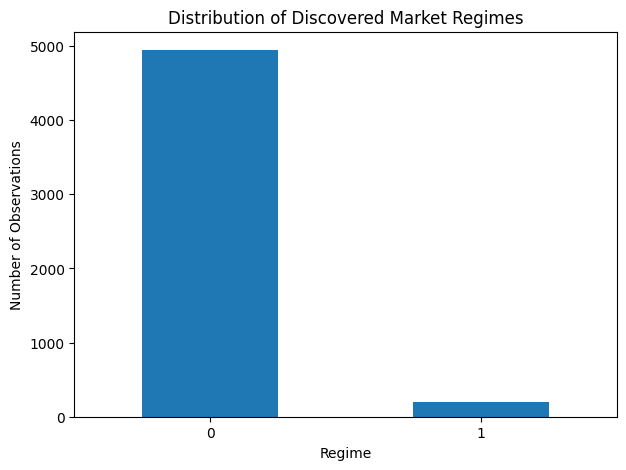

In [89]:
### Regime Distribution

#The distribution of the discovered market regimes is examined to understand
#the relative frequency of normal and high-stress market conditions identified
#by K-Means clustering.

regime_counts = daily_aligned["Regime"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
regime_counts.plot(kind="bar")

plt.title("Distribution of Discovered Market Regimes")
plt.xlabel("Regime")
plt.ylabel("Number of Observations")
plt.xticks(rotation=0)

plt.show()

Regime 0 dominates the dataset, while Regime 1 represents a relatively small
number of observations. This confirms that high-stress market conditions are
rare and concentrated within specific periods, which also explains the class
imbalance observed during supervised modeling.

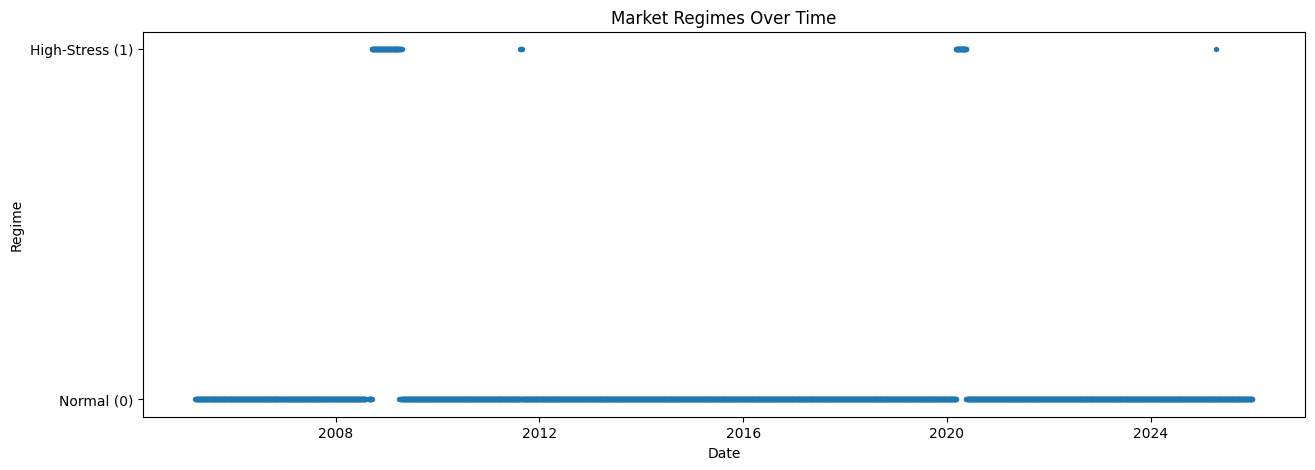

In [90]:
### Regime Timeline

#The regime assignments are plotted over time to examine the temporal
#distribution and persistence of the discovered market regimes. This helps
#identify periods in which the market transitioned from normal conditions to
#high-stress conditions.
plt.figure(figsize=(15, 5))

plt.scatter(
    daily_aligned["Date"],
    daily_aligned["Regime"],
    s=8
)

plt.title("Market Regimes Over Time")
plt.xlabel("Date")
plt.ylabel("Regime")
plt.yticks([0, 1], ["Normal (0)", "High-Stress (1)"])

plt.show()

Regime 1 appears in concentrated periods rather than being randomly distributed
throughout the dataset. The major clusters occur around the 2008–2009 financial
crisis and the 2020 market shock, while most other periods remain in Regime 0.

This temporal clustering supports the interpretation of Regime 1 as a
high-stress market regime.

<Figure size 800x500 with 0 Axes>

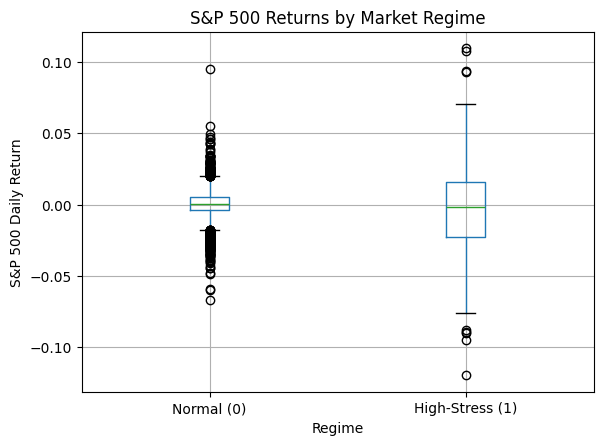

In [91]:
### S&P 500 Returns by Regime

#The distribution of S&P 500 returns is compared across the discovered regimes
#to examine whether high-stress periods are associated with different market
#return behavior.
plt.figure(figsize=(8, 5))

daily_aligned.boxplot(
    column="S&P_500_Return",
    by="Regime"
)

plt.title("S&P 500 Returns by Market Regime")
plt.suptitle("")
plt.xlabel("Regime")
plt.ylabel("S&P 500 Daily Return")
plt.xticks([1, 2], ["Normal (0)", "High-Stress (1)"])

plt.show()

The S&P 500 return distribution is substantially wider during Regime 1 than
during Regime 0. High-stress periods exhibit larger positive and negative daily
movements, indicating greater market volatility and uncertainty.

The median return of Regime 1 is close to zero, suggesting that the defining
characteristic of the high-stress regime is not simply negative returns, but
rather increased dispersion and more extreme market movements.

<Figure size 800x500 with 0 Axes>

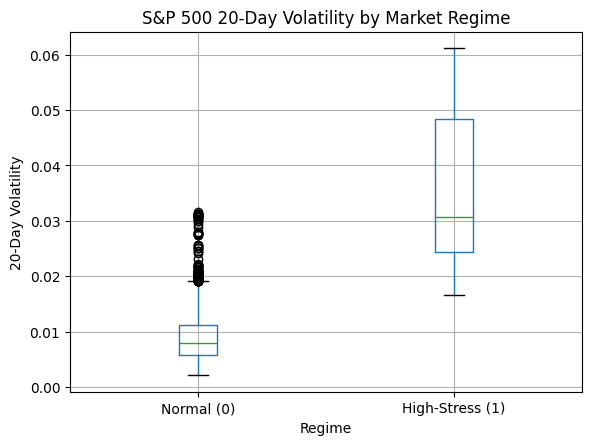

In [92]:
### S&P 500 Volatility by Regime

#The 20-day rolling volatility of the S&P 500 is compared across the discovered
#market regimes to determine whether the high-stress regime is associated with
#greater market volatility than the normal regime.

plt.figure(figsize=(8, 5))

daily_aligned.boxplot(
    column="S&P_500_Volatility_20D",
    by="Regime"
)

plt.title("S&P 500 20-Day Volatility by Market Regime")
plt.suptitle("")
plt.xlabel("Regime")
plt.ylabel("20-Day Volatility")
plt.xticks([1, 2], ["Normal (0)", "High-Stress (1)"])

plt.show()

The 20-day S&P 500 volatility is substantially higher during Regime 1 than
during Regime 0. Regime 1 has a much higher median volatility and a wider
distribution, indicating significantly greater market instability during
high-stress periods.

The clear separation between the two regimes supports the interpretation of
Regime 1 as a high-volatility market regime.

<Figure size 800x500 with 0 Axes>

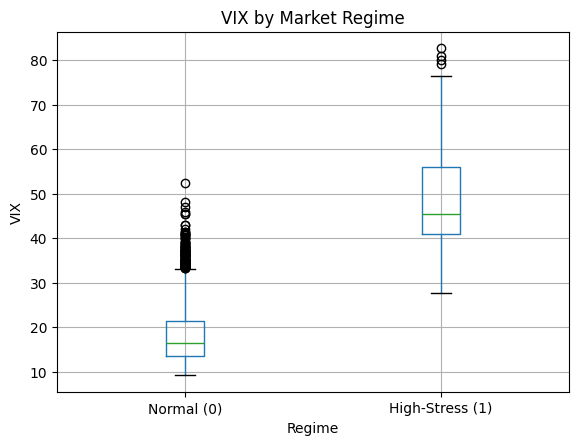

In [93]:
### VIX by Regime

#The VIX index is compared across the discovered market regimes to examine
#whether the high-stress regime is associated with elevated investor
#uncertainty and market fear.

plt.figure(figsize=(8, 5))

daily_aligned.boxplot(
    column="VIX",
    by="Regime"
)

plt.title("VIX by Market Regime")
plt.suptitle("")
plt.xlabel("Regime")
plt.ylabel("VIX")
plt.xticks([1, 2], ["Normal (0)", "High-Stress (1)"])

plt.show()

The VIX distribution shows a clear separation between the two market regimes.
Regime 1 has a substantially higher median VIX than Regime 0, indicating
significantly elevated market uncertainty and investor fear during
high-stress periods.

The wide VIX range in Regime 1 also captures periods of extreme market stress,
further supporting the interpretation of Regime 1 as a high-stress market
regime.

<Figure size 800x500 with 0 Axes>

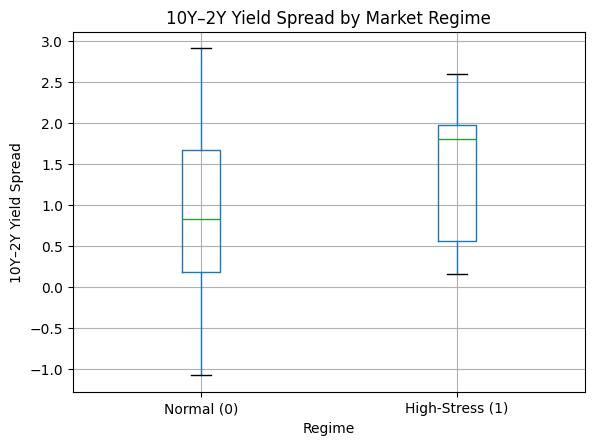

In [94]:
### Yield Spread by Regime

#The 10-year minus 2-year Treasury yield spread is compared across the
#discovered market regimes to examine whether the yield curve behaves
#differently during high-stress market conditions.

plt.figure(figsize=(8, 5))

daily_aligned.boxplot(
    column="Yield_Spread_10Y_2Y",
    by="Regime"
)

plt.title("10Y–2Y Yield Spread by Market Regime")
plt.suptitle("")
plt.xlabel("Regime")
plt.ylabel("10Y–2Y Yield Spread")
plt.xticks([1, 2], ["Normal (0)", "High-Stress (1)"])

plt.show()

The 10Y–2Y yield spread shows a noticeable shift between the two market
regimes. Regime 1 has a substantially higher median spread than Regime 0,
indicating a steeper yield curve during the high-stress periods identified by
the model.

However, the distributions also show considerable variation within Regime 0,
including periods of negative spreads. Therefore, the yield spread should be
interpreted as one component of the overall regime profile rather than as a
standalone indicator of market stress.

<Figure size 800x500 with 0 Axes>

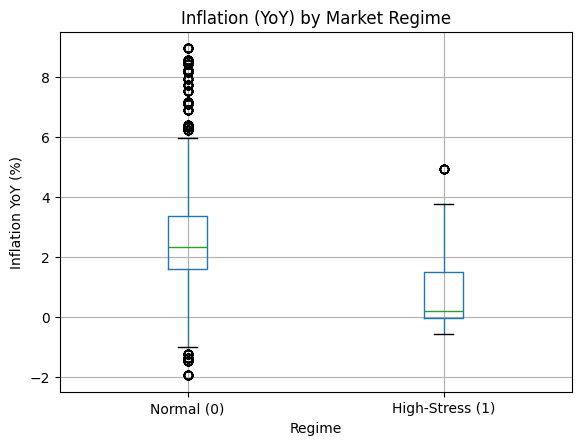

In [95]:
### Inflation by Regime

#Year-over-year inflation is compared across the discovered market regimes to
#examine whether inflationary conditions differ between normal and high-stress
#market periods.

plt.figure(figsize=(8, 5))

daily_aligned.boxplot(
    column="Inflation_YoY",
    by="Regime"
)

plt.title("Inflation (YoY) by Market Regime")
plt.suptitle("")
plt.xlabel("Regime")
plt.ylabel("Inflation YoY (%)")
plt.xticks([1, 2], ["Normal (0)", "High-Stress (1)"])

plt.show()

Inflation differs noticeably across the two regimes. Regime 0 has a higher
median year-over-year inflation rate, while Regime 1 is concentrated around
lower inflation levels.

This indicates that the high-stress regime identified by K-Means is not
primarily characterized by high inflation in this dataset. Instead, the
earlier volatility, return, and VIX analysis provides stronger evidence for
the interpretation of Regime 1 as a market-stress regime.

<Figure size 800x500 with 0 Axes>

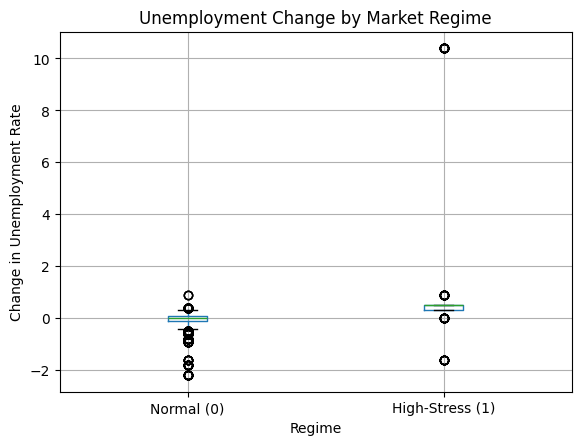

In [96]:
### Unemployment Change by Regime

#The change in the unemployment rate is compared across the discovered market
#regimes to examine whether deterioration in labor-market conditions is
#associated with high-stress market periods.

plt.figure(figsize=(8, 5))

daily_aligned.boxplot(
    column="Unemployment_Change",
    by="Regime"
)

plt.title("Unemployment Change by Market Regime")
plt.suptitle("")
plt.xlabel("Regime")
plt.ylabel("Change in Unemployment Rate")
plt.xticks([1, 2], ["Normal (0)", "High-Stress (1)"])

plt.show()

The distribution of unemployment-rate changes differs between the two regimes.
Regime 0 is centered close to zero, while Regime 1 shows a higher median
increase in unemployment.

Regime 1 also contains extreme positive changes, reflecting periods of severe
labor-market deterioration such as the COVID-19 shock. This provides additional
evidence that the high-stress regime is associated with worsening economic
conditions, although the presence of extreme observations warrants cautious
interpretation.

# **21. Risk Forecasting**

In [97]:
# Create next-day volatility target

daily_aligned["Next_Day_Volatility"] = (
    daily_aligned["S&P_500_Volatility_20D"].shift(-1)
)

print(
    daily_aligned[
        ["Date", "S&P_500_Volatility_20D", "Next_Day_Volatility"]
    ].head()
)

         Date  S&P_500_Volatility_20D  Next_Day_Volatility
60 2005-04-01                0.006502             0.006561
61 2005-04-04                0.006561             0.006196
62 2005-04-05                0.006196             0.006184
63 2005-04-06                0.006184             0.006365
64 2005-04-07                0.006365             0.006240


In [98]:
#Prepare the Risk Forecasting Dataset
risk_data = daily_aligned.dropna(
    subset=["Next_Day_Volatility"]
).copy()

X_risk = risk_data[regime_features].copy()
y_risk = risk_data["Next_Day_Volatility"].copy()

print("X_risk:", X_risk.shape)
print("y_risk:", y_risk.shape)

X_risk: (5144, 38)
y_risk: (5144,)


In [99]:
#Chronological Train/Test Split

risk_split_index = int(len(X_risk) * 0.80)

X_risk_train = X_risk.iloc[:risk_split_index].copy()
X_risk_test = X_risk.iloc[risk_split_index:].copy()

y_risk_train = y_risk.iloc[:risk_split_index].copy()
y_risk_test = y_risk.iloc[risk_split_index:].copy()

print("Risk training:", X_risk_train.shape)
print("Risk test:", X_risk_test.shape)

print("Training dates:",
      risk_data["Date"].iloc[0],
      "to",
      risk_data["Date"].iloc[risk_split_index - 1])

print("Test dates:",
      risk_data["Date"].iloc[risk_split_index],
      "to",
      risk_data["Date"].iloc[-1])

Risk training: (4115, 38)
Risk test: (1029, 38)
Training dates: 2005-04-01 00:00:00 to 2021-11-08 00:00:00
Test dates: 2021-11-09 00:00:00 to 2025-12-29 00:00:00


In [100]:
#Train Risk Forecasting Baseline
risk_model = LinearRegression()

risk_model.fit(
    X_risk_train,
    y_risk_train
)

y_risk_pred = risk_model.predict(X_risk_test)

print("Predictions generated:", len(y_risk_pred))

Predictions generated: 1029


In [101]:
#Evaluate Risk Forecast
mae = mean_absolute_error(y_risk_test, y_risk_pred)
rmse = np.sqrt(mean_squared_error(y_risk_test, y_risk_pred))
r2 = r2_score(y_risk_test, y_risk_pred)

print("Risk Forecasting Results")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Risk Forecasting Results
MAE : 0.0004433187661682516
RMSE: 0.0007690604209848199
R²  : 0.9745064308717347


### Risk Forecasting — Results

The Linear Regression baseline achieved an MAE of 0.000443, an RMSE of
0.000769, and an R² of 0.9745 on the chronological test period.

The high R² indicates that the selected financial features explain a substantial
portion of the variation in next-day S&P 500 volatility. The relatively low
MAE and RMSE also indicate small average forecasting errors.

These results suggest that the available market and macroeconomic features
contain strong information for short-term volatility forecasting.

In [102]:
# Naive baseline: next-day volatility = today's volatility

y_risk_naive = risk_data["S&P_500_Volatility_20D"].iloc[
    risk_split_index:
].values

mae_naive = mean_absolute_error(y_risk_test, y_risk_naive)
rmse_naive = np.sqrt(mean_squared_error(y_risk_test, y_risk_naive))
r2_naive = r2_score(y_risk_test, y_risk_naive)

print("Naive Baseline")
print("MAE :", mae_naive)
print("RMSE:", rmse_naive)
print("R²  :", r2_naive)

Naive Baseline
MAE : 0.00037892914402998045
RMSE: 0.0007893404452418977
R²  : 0.9731441791364308


### Risk Forecasting — Baseline Comparison

The Linear Regression model was compared against a naive persistence baseline,
where the next day's volatility is assumed to equal the current day's
volatility.

The naive baseline achieved an MAE of 0.000379, RMSE of 0.000789, and R² of
0.9731. Linear Regression achieved an MAE of 0.000443, RMSE of 0.000769, and
R² of 0.9745.

The results show that next-day volatility is highly persistent. Although
Linear Regression slightly improves RMSE and R², it does not improve MAE over
the naive baseline. Therefore, the additional features provide only limited
incremental predictive value beyond current volatility.

# **22. Final Interpretation**

The analysis identified two distinct market regimes using K-Means clustering.
Regime 0 represents the dominant normal market condition, while Regime 1 is a
rare, high-stress regime concentrated around major market-stress periods.

EDA supports this interpretation. Regime 1 is characterized by substantially
higher S&P 500 volatility and VIX levels, more extreme daily returns, and
changes in selected macroeconomic indicators. The regime timeline also shows
that high-stress observations are concentrated rather than randomly distributed.

For next-regime prediction, Logistic Regression outperformed Random Forest and
XGBoost on the 2020 validation period. It achieved 96.86% balanced accuracy,
97.54% macro F1, and 94% recall for Regime 1, correctly identifying 49 of 52
high-stress observations.

For risk forecasting, Linear Regression achieved an R² of 0.9745 for next-day
volatility. However, comparison with a naive persistence baseline showed that
current volatility is already a very strong predictor of next-day volatility.
Therefore, the regression model provides only limited incremental improvement.

Overall, the project demonstrates an end-to-end framework for discovering
market regimes, predicting transitions into high-stress conditions, and
forecasting short-term market volatility while preserving the chronological
nature of financial data.

# **23. Limitations**

- **Rare high-stress regime:** Regime 1 represents a small proportion of the
  observations and is concentrated around specific historical periods.

- **Limited final test representation:** The final future holdout contains only
  one Regime-1 observation. Therefore, its high-stress classification metrics
  should not be interpreted as representative of crisis-detection performance.

- **Unsupervised regime labels:** The regimes were discovered using K-Means
  rather than predefined economic labels. Their interpretation is based on
  observed market and macroeconomic characteristics.

- **Historical dependence:** Financial relationships can change over time, so
  strong historical performance does not guarantee identical performance
  during future market conditions.

- **Risk forecast persistence:** Next-day volatility is highly persistent. The
  naive baseline performed very similarly to Linear Regression, indicating
  limited incremental predictive value from the additional features.

- **No causal interpretation:** The analysis identifies associations between
  financial indicators and market regimes but does not establish causal
  relationships.

# **24. Conclusion**

This project developed an end-to-end framework for financial market regime
prediction and short-term risk forecasting using historical market and
macroeconomic data.

K-Means clustering identified two distinct market regimes. Regime 0 represents
the dominant normal market condition, while Regime 1 represents a rare,
high-stress condition. Exploratory analysis showed that Regime 1 is associated
with substantially higher market volatility, elevated VIX levels, and more
extreme market returns, with the major stress periods concentrated around
2008–2009 and 2020.

For next-regime prediction, three classification models were evaluated using
a chronological validation framework. Logistic Regression performed best,
achieving 96.86% balanced accuracy, 97.54% macro F1, and 94% recall for the
high-stress Regime 1 on the 2020 validation period.

For short-term risk forecasting, Linear Regression achieved an R² of 0.9745
for next-day S&P 500 volatility. However, comparison with a naive persistence
baseline showed that current volatility already provides a very strong
prediction of next-day volatility, limiting the incremental benefit of the
additional features.

Overall, the project demonstrates how unsupervised regime discovery and
supervised prediction can be combined with volatility forecasting to create a
data-driven framework for monitoring changing market conditions and potential
periods of elevated financial risk.